## Imports and Loading modules

In [1]:
"""
Imports

"""

import random
import uproot
import awkward as ak
import argparse
import logging
from tqdm import tqdm
from pathlib import Path
import os
import numpy as np

import torch

from torch.utils.data import IterableDataset

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import EdgeConv, global_mean_pool

import h5py
import torch.nn.functional as F
#from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.cuda.amp import GradScaler, autocast
from livelossplot import PlotLosses

from torch.utils.data import Dataset, DataLoader, random_split

from torch_geometric.loader import DataLoader
import torch_cluster

import sys

sys.path.append('/global/cfs/cdirs/m4474/aneek/particlemind_aneek')

from src.data.augmentation import *
from src.data.dataset import *
from src.models.gnn import *
from src.models.contrastive_learning import *


/global/homes/a/aneekj02/.conda/envs/colliderml-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Function for plotting tSNE and UMAP projection 
## and KNN classification and Linear probe classification

In [2]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE

try:
    import umap
    _UMAP_AVAILABLE = True
except ImportError:
    _UMAP_AVAILABLE = False



def visualize_latent_categories(
    category_vectors: dict[str, np.ndarray],
    *,
    # t-SNE kwargs
    tsne_perplexity: float = 30.0,
    tsne_n_iter: int = 1000,
    tsne_random_state: int = 42,
    # UMAP kwargs
    umap_n_neighbors: int = 15,
    umap_min_dist: float = 0.1,
    umap_random_state: int = 42,
    # Visual kwargs
    point_size: float = 18,
    alpha: float = 0.75,
    palette: list[str] | None = None,
    figsize: tuple[float, float] = (14, 6),
    title: str = "Latent Space Projections",
    show_umap: bool = True,
) -> plt.Figure:
    """
    Project and plot latent vectors for multiple categories using t-SNE (and
    optionally UMAP).
 
    Parameters
    ----------
    category_vectors : dict[str, array-like of shape (N_i, D)]
        Keys   → category names (used as legend labels).
        Values → 2-D arrays where each row is one latent vector.
                 All categories must share the same latent dimension D.
 
    tsne_perplexity : float
        t-SNE perplexity (roughly the expected neighbourhood size).
    tsne_n_iter : int
        Number of t-SNE optimisation iterations.
    tsne_random_state : int
        Random seed for t-SNE reproducibility.
 
    umap_n_neighbors : int
        UMAP n_neighbors parameter.
    umap_min_dist : float
        UMAP min_dist parameter.
    umap_random_state : int
        Random seed for UMAP reproducibility.
 
    point_size : float
        Scatter-plot marker size.
    alpha : float
        Marker opacity (0–1).
    palette : list[str] | None
        Custom list of hex/named colours, one per category.
        Defaults to ``matplotlib``'s tab20 qualitative palette.
    figsize : tuple[float, float]
        Figure (width, height) in inches.
    title : str
        Figure suptitle.
    show_umap : bool
        If False (or umap-learn is not installed), only t-SNE is shown.
 
    Returns
    -------
    matplotlib.figure.Figure
        The figure containing the projection plots. Call ``plt.show()`` or
        ``fig.savefig(...)`` on the returned object.
 
    Raises
    ------
    ValueError
        If ``category_vectors`` is empty, or the arrays have inconsistent
        latent dimensions.
    ImportError
        If ``show_umap=True`` but ``umap-learn`` is not installed.
    """
    if not category_vectors:
        raise ValueError("`category_vectors` must contain at least one category.")
 
    if show_umap and not _UMAP_AVAILABLE:
        raise ImportError(
            "umap-learn is not installed. "
            "Run `pip install umap-learn` or pass `show_umap=False`."
        )
 
    # ── 1. Stack vectors and build label array ───────────────────────────────
    names   = list(category_vectors.keys())
    arrays  = [np.asarray(v, dtype=np.float32) for v in category_vectors.values()]
 
    dims = {a.ndim for a in arrays}
    if dims != {2}:
        raise ValueError("Every value in `category_vectors` must be a 2-D array.")
 
    latent_dims = {a.shape[1] for a in arrays}
    if len(latent_dims) > 1:
        raise ValueError(
            f"All categories must share the same latent dimension; "
            f"found {latent_dims}."
        )
 
    X      = np.vstack(arrays)                          # (N_total, D)
    sizes  = [len(a) for a in arrays]
    labels = np.concatenate([
        np.full(n, i, dtype=int) for i, n in enumerate(sizes)
    ])                                                   # (N_total,)
 
    # ── 2. Colour palette ────────────────────────────────────────────────────
    n_cats = len(names)
    if palette is None:
        cmap    = plt.get_cmap("tab20")
        palette = [cmap(i / max(n_cats - 1, 1)) for i in range(n_cats)]
    if len(palette) < n_cats:
        raise ValueError(
            f"palette has {len(palette)} colours but there are {n_cats} categories."
        )
    colours = np.array([palette[labels[i]] for i in range(len(labels))])
 
    # ── 3. Projections ───────────────────────────────────────────────────────
    n_cols = 2 if show_umap else 1
    fig, axes = plt.subplots(1, n_cols, figsize=figsize)
    if n_cols == 1:
        axes = [axes]
 
    # — t-SNE —
    effective_perplexity = min(tsne_perplexity, len(X) - 1)
    tsne = TSNE(
        n_components=2,
        perplexity=effective_perplexity,
        max_iter=tsne_n_iter,
        random_state=tsne_random_state,
        init="pca",
        learning_rate="auto",
    )
    Z_tsne = tsne.fit_transform(X)
    _scatter(axes[0], Z_tsne, colours, labels, names, palette,
             point_size, alpha, "t-SNE")
 
    # — UMAP —
    if show_umap:
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=min(umap_n_neighbors, len(X) - 1),
            min_dist=umap_min_dist,
            random_state=umap_random_state,
        )
        Z_umap = reducer.fit_transform(X)
        _scatter(axes[1], Z_umap, colours, labels, names, palette,
                 point_size, alpha, "UMAP")
 
    # ── 4. Shared legend ─────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(color=palette[i], label=f"{names[i]}  (n={sizes[i]})")
        for i in range(n_cats)
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=min(n_cats, 5),
        frameon=True,
        fontsize=9,
        bbox_to_anchor=(0.5, -0.04),
    )
 
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    #return fig
 
 
# ──────────────────────────────────────────────────────────────────────────────
# Helper
# ──────────────────────────────────────────────────────────────────────────────
 
def _scatter(
    ax: plt.Axes,
    Z: np.ndarray,
    colours,
    labels: np.ndarray,
    names: list[str],
    palette,
    point_size: float,
    alpha: float,
    method_name: str,
) -> None:
    """Render one scatter subplot."""
    ax.scatter(Z[:, 0], Z[:, 1], c=colours, s=point_size, alpha=alpha,
               linewidths=0)
    ax.set_title(method_name, fontsize=22, pad=8)
    ax.set_xlabel("Component 1", fontsize=20)
    ax.set_ylabel("Component 2", fontsize=20)
    ax.tick_params(labelsize=8)
    ax.set_aspect("auto")
    # Light grid
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
    ax.set_axisbelow(True)
 



"""
KNN Classification Helper Function
"""

import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

def evaluate_latent_space_knn(
    vectors_a: np.ndarray,
    vectors_b: np.ndarray,
    k: int = 5,
    test_split: float = 0.2,
    random_seed: int = 42,
    normalize_vectors: bool = True,
) -> float:
    """
    Evaluate latent space embedding quality via KNN classification accuracy.

    Parameters
    ----------
    vectors_a          : (N, D) array of latent vectors for category A
    vectors_b          : (M, D) array of latent vectors for category B
    k                  : number of nearest neighbours
    test_split         : fraction of data held out for testing
    random_seed        : reproducibility seed
    normalize_vectors  : L2-normalise vectors before classification

    Returns
    -------
    accuracy : float in [0, 1]
    """
    X = np.concatenate([vectors_a, vectors_b], axis=0)
    y = np.array([0] * len(vectors_a) + [1] * len(vectors_b))

    if normalize_vectors:
        X = normalize(X, norm="l2")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_split,
        stratify=y,
        random_state=random_seed,
    )

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracy = knn.score(X_test, y_test)

    return float(accuracy)


"""
Linear probe classification helper function
"""

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


def linear_probe_classification(
    latents: np.ndarray,
    labels: np.ndarray,
    test_size: float = 0.2,
    random_state: int = 42,
    scale: bool = True,
    verbose: bool = True,
) -> dict:
    """
    Trains a logistic regression linear probe on latent representations
    and reports binary classification accuracy.

    Args:
        latents:      Array of shape (N, D) — N samples, D-dimensional latents.
        labels:       Array of shape (N,) with binary class labels (0 or 1).
        test_size:    Fraction of data held out for evaluation.
        random_state: Seed for reproducibility.
        scale:        Whether to standardize latents before probing.
        verbose:      Whether to print a classification report.

    Returns:
        dict with keys:
            - train_acc   : accuracy on the training split
            - test_acc    : accuracy on the held-out test split
            - probe       : the fitted LogisticRegression model
            - scaler      : the fitted StandardScaler (or None)
    """
    X_train, X_test, y_train, y_test = train_test_split(
        latents, labels, test_size=test_size, random_state=random_state, stratify=labels
    )

    scaler = None
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

    probe = LogisticRegression(max_iter=1000, random_state=random_state)
    probe.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, probe.predict(X_train))
    test_acc  = accuracy_score(y_test,  probe.predict(X_test))

    if verbose:
        print(f"Train accuracy : {train_acc:.4f}")
        print(f"Test  accuracy : {test_acc:.4f}")
        #print("\nClassification report (test set):")
        #print(classification_report(y_test, probe.predict(X_test)))

    return {"train_acc": train_acc, "test_acc": test_acc, "probe": probe, "scaler": scaler}

### Usage: loading the latents and plotting

In [15]:
"""
Loading latents by trained PointEncoder model (64-dim)
"""

folder = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml_latest/pointnet_models_ttbar_dihiggs_ggf_mixed_events_no_edges/'


"""
Loading the latents of orginal events
"""

latents_ttbar_og = np.loadtxt(folder+'ttbar_original_900-1000_latents_epoch_18.txt')
latents_dihiggs_og = np.loadtxt(folder+'dihiggs_original_900-1000_latents_epoch_18.txt')
latents_ggf_og = np.loadtxt(folder+'ggf_original_900-1000_latents_epoch_18.txt')


"""
Loading the latents of augmented events
"""

latents_ttbar_aug = np.loadtxt(folder+'ttbar_augmented_900-1000_latents_epoch_18.txt')
latents_dihiggs_aug = np.loadtxt(folder+'dihiggs_augmented_900-1000_latents_epoch_18.txt')
latents_ggf_aug = np.loadtxt(folder+'ggf_augmented_900-1000_latents_epoch_18.txt')



In [29]:
"""
Linear probe classification -- PointNetEncoder
"""

labels = np.array([0]*100+[1]*100)


print('classifying ttbar and dihiggs with linear probe---')

data = np.concatenate([latents_ttbar_og, latents_dihiggs_og], axis=0)

linear_probe_classification(latents=data, labels=labels, random_state=44)


print('classifying ttbar and ggf with linear probe---')

data = np.concatenate([latents_ttbar_og, latents_ggf_og], axis=0)

linear_probe_classification(latents=data, labels=labels, random_state=49)


print('classifying dihiggs and ggf with linear probe---')

data = np.concatenate([latents_dihiggs_og, latents_ggf_og], axis=0)

linear_probe_classification(latents=data, labels=labels, random_state=48)





classifying ttbar and dihiggs with linear probe---
Train accuracy : 0.7875
Test  accuracy : 0.6500
classifying ttbar and ggf with linear probe---
Train accuracy : 0.8562
Test  accuracy : 0.8000
classifying dihiggs and ggf with linear probe---
Train accuracy : 0.7937
Test  accuracy : 0.6750


{'train_acc': 0.79375,
 'test_acc': 0.675,
 'probe': LogisticRegression(max_iter=1000, random_state=48),
 'scaler': StandardScaler()}

In [30]:
"""
Loading latents by trained GravNetEncoder model (64-dim)
"""

folder = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml_latest/gravnet_models_ttbar_dihiggs_ggf_mixed_events_no_edges/'


"""
Loading the latents of orginal events
"""

latents_ttbar_og = np.loadtxt(folder+'ttbar_original_900-1000_latents_epoch_18.txt')
latents_dihiggs_og = np.loadtxt(folder+'dihiggs_original_900-1000_latents_epoch_18.txt')
latents_ggf_og = np.loadtxt(folder+'ggf_original_900-1000_latents_epoch_18.txt')


"""
Loading the latents of augmented events
"""

latents_ttbar_aug = np.loadtxt(folder+'ttbar_augmented_900-1000_latents_epoch_18.txt')
latents_dihiggs_aug = np.loadtxt(folder+'dihiggs_augmented_900-1000_latents_epoch_18.txt')
latents_ggf_aug = np.loadtxt(folder+'ggf_augmented_900-1000_latents_epoch_18.txt')



In [49]:
"""
Linear probe classification -- GravNetEncoder
"""
labels = np.array([0]*100+[1]*100)


print('classifying ttbar and dihiggs with linear probe---')

data = np.concatenate([latents_ttbar_og, latents_dihiggs_og], axis=0)

linear_probe_classification(latents=data, labels=labels, random_state=59)


print('classifying ttbar and ggf with linear probe---')

data = np.concatenate([latents_ttbar_og, latents_ggf_og], axis=0)

linear_probe_classification(latents=data, labels=labels, random_state=59)


print('classifying dihiggs and ggf with linear probe---')

data = np.concatenate([latents_dihiggs_og, latents_ggf_og], axis=0)

linear_probe_classification(latents=data, labels=labels, random_state=59)


classifying ttbar and dihiggs with linear probe---
Train accuracy : 0.7188
Test  accuracy : 0.6000
classifying ttbar and ggf with linear probe---
Train accuracy : 0.7812
Test  accuracy : 0.7000
classifying dihiggs and ggf with linear probe---
Train accuracy : 0.7063
Test  accuracy : 0.5750


{'train_acc': 0.70625,
 'test_acc': 0.575,
 'probe': LogisticRegression(max_iter=1000, random_state=59),
 'scaler': StandardScaler()}

/global/homes/a/aneekj02/.conda/envs/colliderml-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/global/homes/a/aneekj02/.conda/envs/colliderml-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


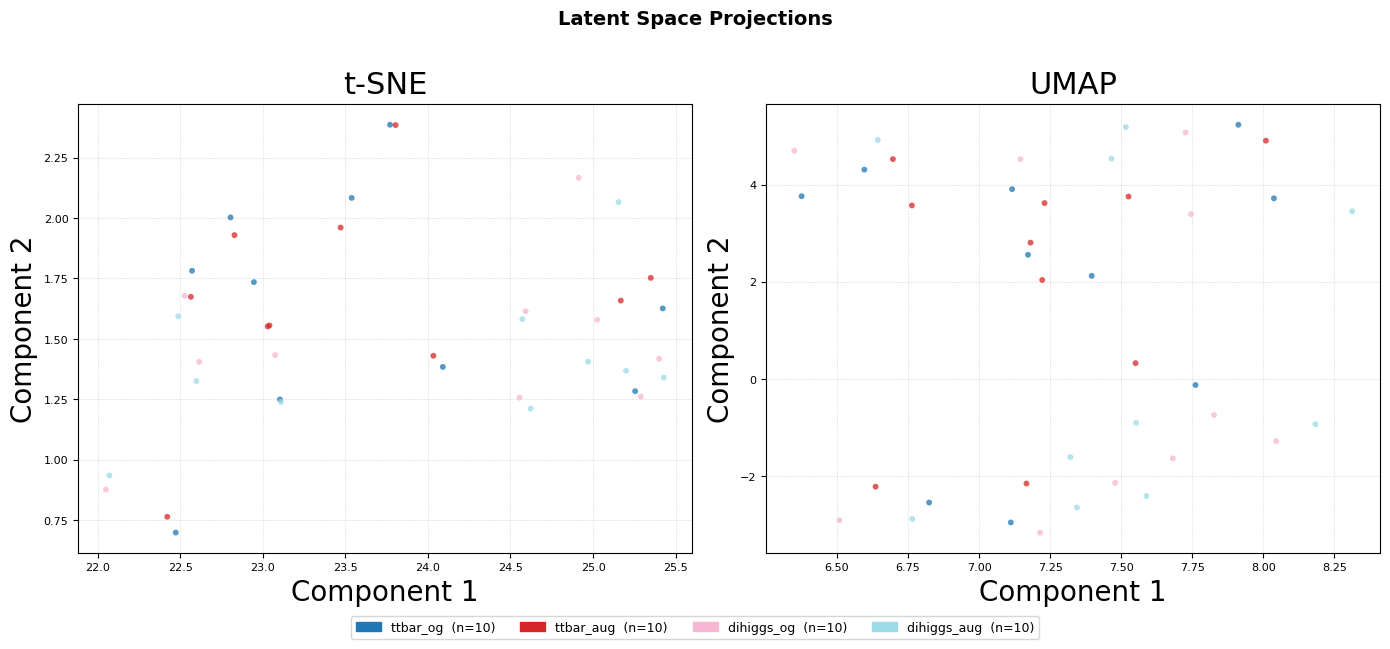

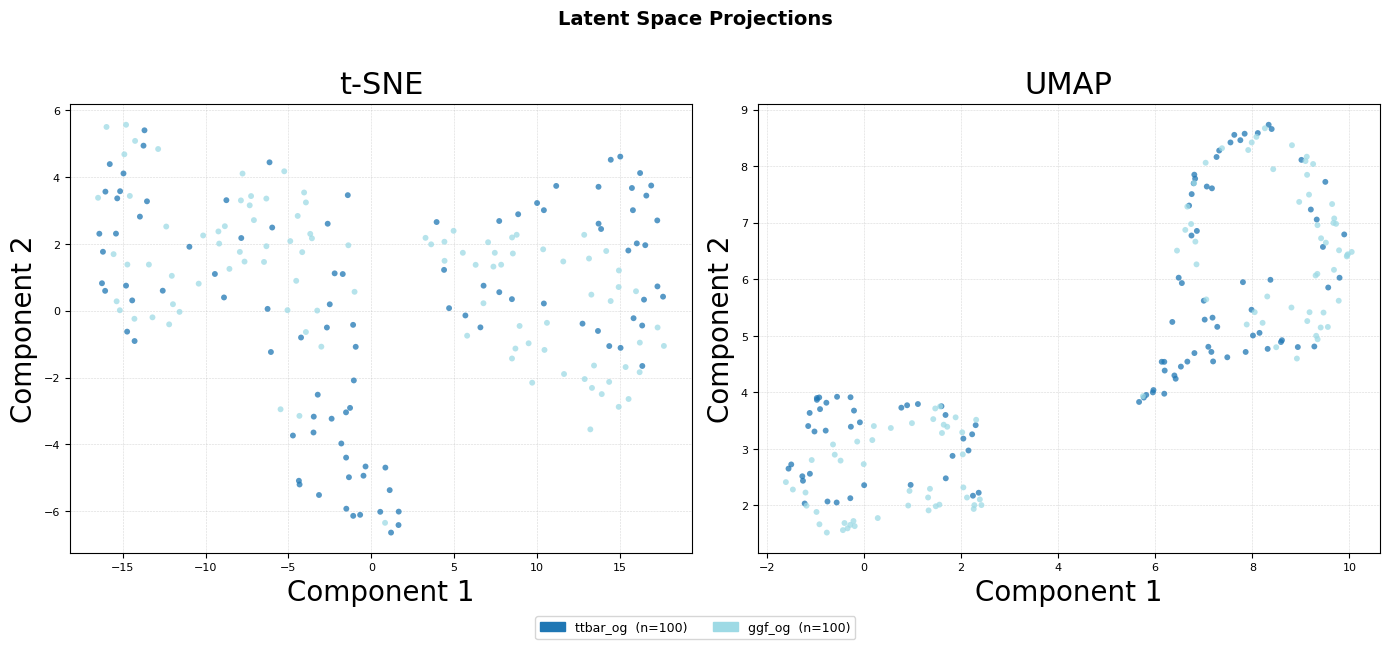

In [89]:
"""
Plotting the latents
"""

dict_latent = {'ttbar_og': latents_ttbar_og[0:10], 'ttbar_aug': latents_ttbar_aug[0:10], 'dihiggs_og': latents_dihiggs_og[0:10], 'dihiggs_aug': latents_dihiggs_aug[0:10]}

visualize_latent_categories(dict_latent)


dict_latent = {'ttbar_og': latents_ttbar_og[0:100], 'ggf_og': latents_ggf_og[0:100]}

visualize_latent_categories(dict_latent)




In [90]:

vec_1 = np.random.random((100,32))
vec_2 = np.random.random((100,32))


print('k=12')
print('KNN classification acccuracy (ttbar-dihiggs):', evaluate_latent_space_knn(latents_ttbar_og, latents_dihiggs_og, k=12))
print('KNN classification acccuracy (ttbar-ggf):', evaluate_latent_space_knn(latents_ttbar_og, latents_ggf_og, k=12))
print('KNN classification acccuracy (dihiggs-ggf):', evaluate_latent_space_knn(latents_dihiggs_og, latents_ggf_og, k=12))


print('k=6')
print('KNN classification acccuracy (ttbar-dihiggs):', evaluate_latent_space_knn(latents_ttbar_og, latents_dihiggs_og, k=6))
print('KNN classification acccuracy (ttbar-ggf):', evaluate_latent_space_knn(latents_ttbar_og, latents_ggf_og, k=6))
print('KNN classification acccuracy (dihiggs-ggf):', evaluate_latent_space_knn(latents_dihiggs_og, latents_ggf_og, k=6))


print('k=18')
print('KNN classification acccuracy (ttbar-dihiggs):', evaluate_latent_space_knn(latents_ttbar_og, latents_dihiggs_og, k=18))
print('KNN classification acccuracy (ttbar-ggf):', evaluate_latent_space_knn(latents_ttbar_og, latents_ggf_og, k=18))
print('KNN classification acccuracy (dihiggs-ggf):', evaluate_latent_space_knn(latents_dihiggs_og, latents_ggf_og, k=18))


print('k=3')
print('KNN classification acccuracy (ttbar-dihiggs):', evaluate_latent_space_knn(latents_ttbar_og, latents_dihiggs_og, k=3))
print('KNN classification acccuracy (ttbar-ggf):', evaluate_latent_space_knn(latents_ttbar_og, latents_ggf_og, k=3))
print('KNN classification acccuracy (dihiggs-ggf):', evaluate_latent_space_knn(latents_dihiggs_og, latents_ggf_og, k=3))



k=12
KNN classification acccuracy (ttbar-dihiggs): 0.525
KNN classification acccuracy (ttbar-ggf): 0.7
KNN classification acccuracy (dihiggs-ggf): 0.575
k=6
KNN classification acccuracy (ttbar-dihiggs): 0.525
KNN classification acccuracy (ttbar-ggf): 0.675
KNN classification acccuracy (dihiggs-ggf): 0.45
k=18
KNN classification acccuracy (ttbar-dihiggs): 0.425
KNN classification acccuracy (ttbar-ggf): 0.725
KNN classification acccuracy (dihiggs-ggf): 0.65
k=3
KNN classification acccuracy (ttbar-dihiggs): 0.5
KNN classification acccuracy (ttbar-ggf): 0.7
KNN classification acccuracy (dihiggs-ggf): 0.45


In [10]:
"""
Loading latents by trained GravNetEncoder model (32-dim)
"""

folder = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml_latest/gravnet_models_ttbar_dihiggs_ggf_mixed_events_no_edges/reduced_'


"""
Loading the latents of orginal events
"""

latents_ttbar_og = np.loadtxt(folder+'ttbar_original_900-1000_latents_epoch_18.txt')
latents_dihiggs_og = np.loadtxt(folder+'dihiggs_original_900-1000_latents_epoch_18.txt')
latents_ggf_og = np.loadtxt(folder+'ggf_original_900-1000_latents_epoch_18.txt')


"""
Loading the latents of augmented events
"""

latents_ttbar_aug = np.loadtxt(folder+'ttbar_augmented_900-1000_latents_epoch_18.txt')
latents_dihiggs_aug = np.loadtxt(folder+'dihiggs_augmented_900-1000_latents_epoch_18.txt')
latents_ggf_aug = np.loadtxt(folder+'ggf_augmented_900-1000_latents_epoch_18.txt')



/global/homes/a/aneekj02/.conda/envs/colliderml-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/global/homes/a/aneekj02/.conda/envs/colliderml-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


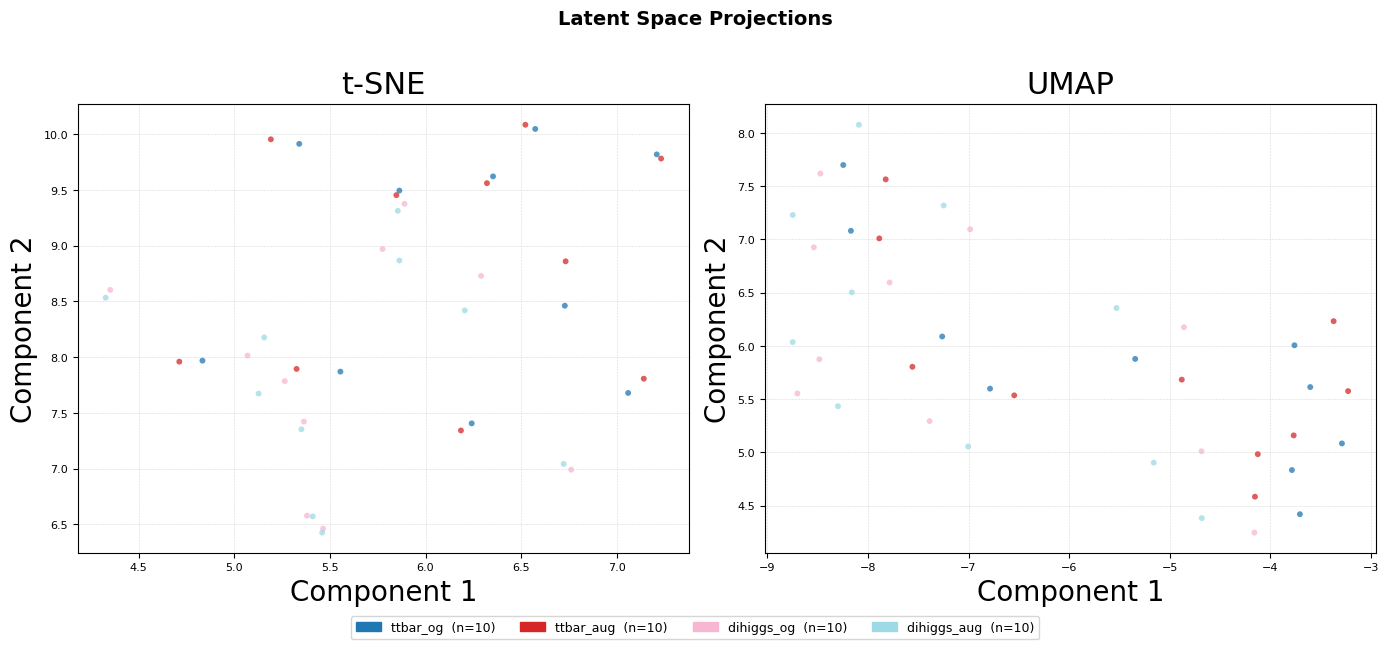

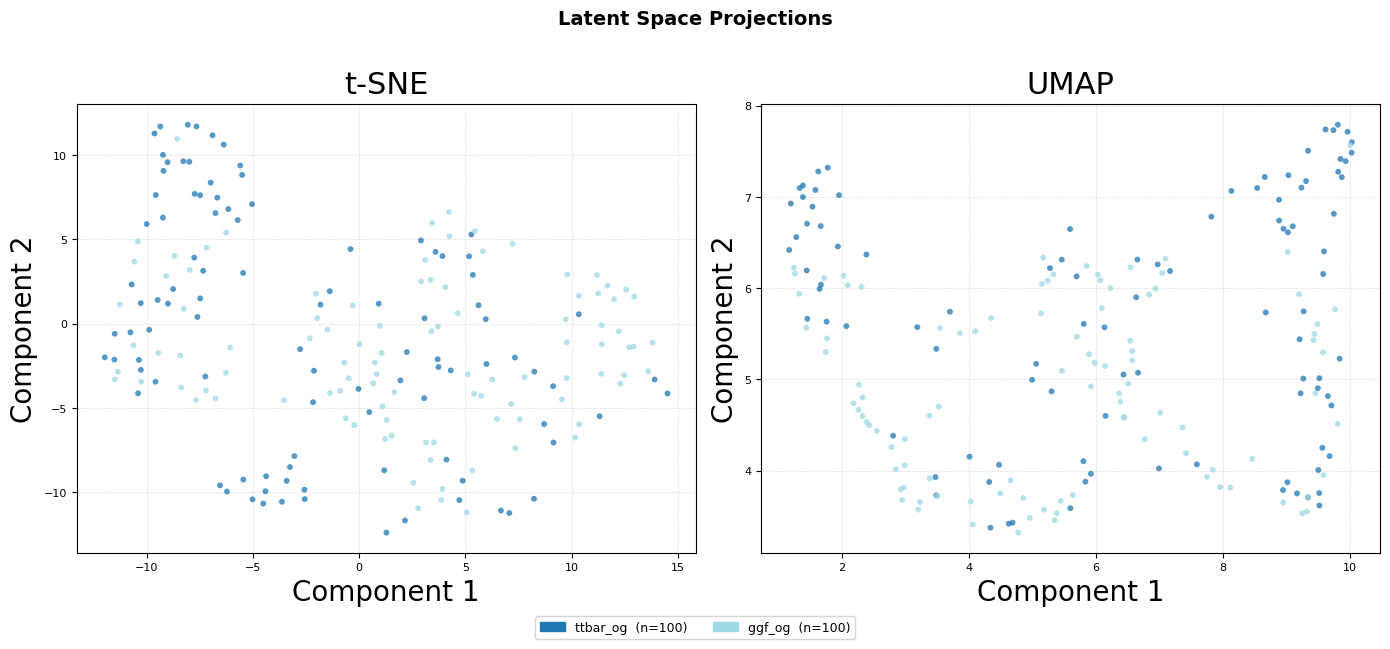

In [13]:
"""
Plotting the latents
"""

dict_latent = {'ttbar_og': latents_ttbar_og[0:10], 'ttbar_aug': latents_ttbar_aug[0:10], 'dihiggs_og': latents_dihiggs_og[0:10], 'dihiggs_aug': latents_dihiggs_aug[0:10]}

visualize_latent_categories(dict_latent)


dict_latent = {'ttbar_og': latents_ttbar_og[0:100], 'ggf_og': latents_ggf_og[0:100]}

visualize_latent_categories(dict_latent)

In [14]:


print('k=12')
print('KNN classification acccuracy (ttbar-dihiggs):', evaluate_latent_space_knn(latents_ttbar_og, latents_dihiggs_og, k=12))
print('KNN classification acccuracy (ttbar-ggf):', evaluate_latent_space_knn(latents_ttbar_og, latents_ggf_og, k=12))
print('KNN classification acccuracy (dihiggs-ggf):', evaluate_latent_space_knn(latents_dihiggs_og, latents_ggf_og, k=12))


print('k=6')
print('KNN classification acccuracy (ttbar-dihiggs):', evaluate_latent_space_knn(latents_ttbar_og, latents_dihiggs_og, k=6))
print('KNN classification acccuracy (ttbar-ggf):', evaluate_latent_space_knn(latents_ttbar_og, latents_ggf_og, k=6))
print('KNN classification acccuracy (dihiggs-ggf):', evaluate_latent_space_knn(latents_dihiggs_og, latents_ggf_og, k=6))


print('k=18')
print('KNN classification acccuracy (ttbar-dihiggs):', evaluate_latent_space_knn(latents_ttbar_og, latents_dihiggs_og, k=18))
print('KNN classification acccuracy (ttbar-ggf):', evaluate_latent_space_knn(latents_ttbar_og, latents_ggf_og, k=18))
print('KNN classification acccuracy (dihiggs-ggf):', evaluate_latent_space_knn(latents_dihiggs_og, latents_ggf_og, k=18))


print('k=3')
print('KNN classification acccuracy (ttbar-dihiggs):', evaluate_latent_space_knn(latents_ttbar_og, latents_dihiggs_og, k=3))
print('KNN classification acccuracy (ttbar-ggf):', evaluate_latent_space_knn(latents_ttbar_og, latents_ggf_og, k=3))
print('KNN classification acccuracy (dihiggs-ggf):', evaluate_latent_space_knn(latents_dihiggs_og, latents_ggf_og, k=3))



k=12
KNN classification acccuracy (ttbar-dihiggs): 0.6
KNN classification acccuracy (ttbar-ggf): 0.725
KNN classification acccuracy (dihiggs-ggf): 0.6
k=6
KNN classification acccuracy (ttbar-dihiggs): 0.6
KNN classification acccuracy (ttbar-ggf): 0.675
KNN classification acccuracy (dihiggs-ggf): 0.525
k=18
KNN classification acccuracy (ttbar-dihiggs): 0.575
KNN classification acccuracy (ttbar-ggf): 0.725
KNN classification acccuracy (dihiggs-ggf): 0.675
k=3
KNN classification acccuracy (ttbar-dihiggs): 0.475
KNN classification acccuracy (ttbar-ggf): 0.7
KNN classification acccuracy (dihiggs-ggf): 0.65


## Function for Cosine similarity and structure of the latent space

In [3]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from itertools import combinations


def analyze_latent_similarity(
    latents_original: np.ndarray,
    latents_augmented: np.ndarray,
    *,
    n_negative_samples: int | None = 1000000,
    bins: int = 60,
    figsize: tuple[float, float] = (12, 5),
    title: str = "Cosine Similarity: Positive vs Negative Pairs",
) -> dict:
    """
    Compute and plot cosine similarity distributions for positive and negative pairs.

    Parameters
    ----------
    latents_original : np.ndarray of shape (N, D)
        Latent vectors of the original events.
    latents_augmented : np.ndarray of shape (N, D)
        Latent vectors of the corresponding augmented events.
        Must be the same length as latents_original — index correspondence is assumed.

    n_negative_samples : int | None
        Number of negative pairs to randomly sample (to avoid O(N²) blowup).
        Set to None to use ALL possible negative pairs.
    bins : int
        Number of histogram bins.
    figsize : tuple
        Figure size.
    title : str
        Plot title.

    Returns
    -------
    dict with keys:
        'pos_similarities'  : np.ndarray of per-pair cosine similarities
        'neg_similarities'  : np.ndarray of sampled negative cosine similarities
        'mean_pos'          : float
        'mean_neg'          : float
    """
    assert latents_original.shape == latents_augmented.shape, (
        f"Shape mismatch: {latents_original.shape} vs {latents_augmented.shape}"
    )

    N = len(latents_original)

    # ── 1. L2-normalise so dot product = cosine similarity ───────────────────
    orig_norm = normalize(latents_original, norm="l2")   # (N, D)
    aug_norm  = normalize(latents_augmented, norm="l2")  # (N, D)

    # ── 2. Positive pairs: dot(orig_i, aug_i) ───────────────────────────────
    pos_similarities = np.sum(orig_norm * aug_norm, axis=1)  # (N,)

    # ── 3. Negative pairs: dot(orig_i, aug_j) for i ≠ j ────────────────────
    # Full similarity matrix between all originals and all augmented
    sim_matrix = orig_norm @ aug_norm.T   # (N, N)

    # Mask out the diagonal (positive pairs)
    mask = ~np.eye(N, dtype=bool)
    all_neg_sims = sim_matrix[mask]       # (N*(N-1),)

    if n_negative_samples is not None and n_negative_samples < len(all_neg_sims):
        rng = np.random.default_rng(42)
        neg_similarities = rng.choice(all_neg_sims, size=n_negative_samples, replace=False)
    else:
        neg_similarities = all_neg_sims

    # ── 4. Print summary ─────────────────────────────────────────────────────
    mean_pos = float(np.mean(pos_similarities))
    mean_neg = float(np.mean(neg_similarities))

    std_pos = float(np.std(pos_similarities))
    std_neg = float(np.std(neg_similarities))

    print(f"Number of events        : {N}")
    print(f"Positive pairs          : {N}")
    print(f"Negative pairs (used)   : {len(neg_similarities):,}")
    print(f"─" * 40)
    print(f"Mean cosine sim (positive) : {mean_pos:.4f}")
    print(f"Standard deviation cosine sim (positive) : {std_pos:.4f}")
    print(f"Mean cosine sim (negative) : {mean_neg:.4f}")
    print(f"Standard deviation cosine sim (negative) : {std_neg:.4f}")
    print(f"Separation (pos - neg)     : {mean_pos - mean_neg:.4f}")

    # ── 5. Histogram ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots( figsize=figsize)

    shared_range = (
        min(pos_similarities.min(), neg_similarities.min()) - 0.05,
        max(pos_similarities.max(), neg_similarities.max()) + 0.05,
    )

    # Overlaid plot
    axes.hist(neg_similarities, bins=bins, range=shared_range,
                 color="steelblue", alpha=0.6, density=True, label=f"Negative  (μ={mean_neg:.3f})")
    axes.hist(pos_similarities, bins=bins, range=shared_range,
                 color="tomato",    alpha=0.7, density=True, label=f"Positive  (μ={mean_pos:.3f})")
    axes.axvline(mean_neg, color="steelblue", linestyle="--", linewidth=1.2)
    axes.axvline(mean_pos, color="tomato",    linestyle="--", linewidth=1.2)
    axes.set_xlabel("Cosine Similarity")
    axes.set_ylabel("Density")
    axes.set_title("Overlaid")
    axes.legend(fontsize=9)
    axes.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)

    # Side-by-side plot
    fig2, (ax_pos, ax_neg) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

    ax_pos.hist(pos_similarities, bins=bins, range=shared_range,
                color="tomato", alpha=0.8, density=True)
    ax_pos.axvline(mean_pos, color="tomato", linestyle="--", linewidth=1.2)
    ax_pos.set_ylabel("Density")
    ax_pos.set_title(f"Positive pairs  (μ={mean_pos:.3f})")
    ax_pos.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)

    ax_neg.hist(neg_similarities, bins=bins, range=shared_range,
                color="steelblue", alpha=0.8, density=True)
    ax_neg.axvline(mean_neg, color="steelblue", linestyle="--", linewidth=1.2)
    ax_neg.set_xlabel("Cosine Similarity")
    ax_neg.set_ylabel("Density")
    ax_neg.set_title(f"Negative pairs  (μ={mean_neg:.3f})")
    ax_neg.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)

    return {
        "pos_similarities": pos_similarities,
        "neg_similarities": neg_similarities,
        "mean_pos": mean_pos,
        "mean_neg": mean_neg,
    }





import numpy as np
import matplotlib.pyplot as plt

def analyze_latent_space(latents, center=True, plot=True, tol=1e-6):
    """
    Analyze PCA spectrum and dimensionality of latent vectors.

    Args:
        latents: array of shape (N, D)
        center: whether to subtract mean before PCA
        plot: whether to plot spectrum
        tol: threshold for detecting near-zero eigenvalues

    Returns:
        dict of computed statistics
    """

    X = np.asarray(latents)
    N, D = X.shape

    # Centering
    if center:
        X = X - X.mean(axis=0, keepdims=True)

    # Covariance matrix
    cov = (X.T @ X) / (N - 1)

    # Eigenvalues (sorted descending)
    eigvals = np.linalg.eigvalsh(cov)[::-1]

    # Normalize to get explained variance ratio
    total_var = eigvals.sum()
    explained = eigvals / (total_var + 1e-12)

    # Cumulative explained variance
    cum_explained = np.cumsum(explained)

    # Effective dimension (entropy-based)
    entropy = -np.sum(explained * np.log(explained + 1e-12))
    effective_dim = np.exp(entropy)

    # Participation ratio (another notion of effective dimension)
    participation_ratio = (np.sum(eigvals) ** 2) / (np.sum(eigvals**2) + 1e-12)

    # Rank estimate (non-negligible eigenvalues)
    rank_est = np.sum(eigvals > tol * eigvals[0])

    var_95 = D-np.sum(cum_explained >= 0.95)+1

    # Collapse diagnostics
    collapse_flag = rank_est < D * 0.5  # heuristic
    top_heavy = explained[0] > 0.5      # one direction dominates

    # Print summary
    print(f"Shape: N={N}, D={D}")
    print(f"Total variance: {total_var:.4e}")
    print(f"Top eigenvalue fraction: {explained[0]:.4f}")
    print(f"Effective dimension (entropy): {effective_dim:.2f}")
    print(f"Participation ratio: {participation_ratio:.2f}")
    print(f"Estimated rank: {rank_est}/{D}")
    print(f"95% variance is in {var_95}/{D} dimensions")

    if collapse_flag:
        print("⚠️ Possible dimensional collapse (rank significantly reduced)")
    if top_heavy:
        print("⚠️ Strong anisotropy (one principal direction dominates)")
    if not collapse_flag and not top_heavy:
        print("✅ No obvious collapse")

    # Plot
    if plot:
        fig, ax = plt.subplots(figsize=(6, 4))

        ax.plot(explained, marker='o', markersize=3, label="Explained variance")
        ax.plot(cum_explained, linestyle='--', label="Cumulative")

        ax.set_xlabel("Principal component index")
        ax.set_ylabel("Variance fraction")
        ax.set_title("PCA Spectrum")
        ax.set_yscale("log")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend()

        plt.tight_layout()
        plt.show()

    return {
        "eigvals": eigvals,
        "explained_variance": explained,
        "cumulative_variance": cum_explained,
        "effective_dim_entropy": effective_dim,
        "participation_ratio": participation_ratio,
        "rank_estimate": rank_est,
        "collapse_flag": collapse_flag,
        "var_95": var_95
    }

### Usage: Loading the latents and getting cosine similarity statistics

In [20]:
"""
Loading latents by trained PointEncoder model (32-dim)
"""

folder = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml_latest/pointnet_models_ttbar_dihiggs_ggf_mixed_events_no_edges/'


"""
Loading the latents of orginal events
"""

latents_ttbar_og = np.loadtxt(folder+'ttbar_original_900-1000_latents_epoch_18.txt')
latents_dihiggs_og = np.loadtxt(folder+'dihiggs_original_900-1000_latents_epoch_18.txt')
latents_ggf_og = np.loadtxt(folder+'ggf_original_900-1000_latents_epoch_18.txt')


"""
Loading the latents of augmented events
"""


latents_ttbar_aug = np.loadtxt(folder+'ttbar_augmented_900-1000_latents_epoch_18.txt')
latents_dihiggs_aug = np.loadtxt(folder+'dihiggs_augmented_900-1000_latents_epoch_18.txt')
latents_ggf_aug = np.loadtxt(folder+'ggf_augmented_900-1000_latents_epoch_18.txt')


latents_og = np.vstack([latents_ttbar_og, latents_dihiggs_og, latents_ggf_og])
latents_aug = np.vstack([latents_ttbar_aug, latents_dihiggs_aug, latents_ggf_aug])

Number of events        : 300
Positive pairs          : 300
Negative pairs (used)   : 89,700
────────────────────────────────────────
Mean cosine sim (positive) : 0.9448
Standard deviation cosine sim (positive) : 0.0597
Mean cosine sim (negative) : 0.0965
Standard deviation cosine sim (negative) : 0.4713
Separation (pos - neg)     : 0.8483


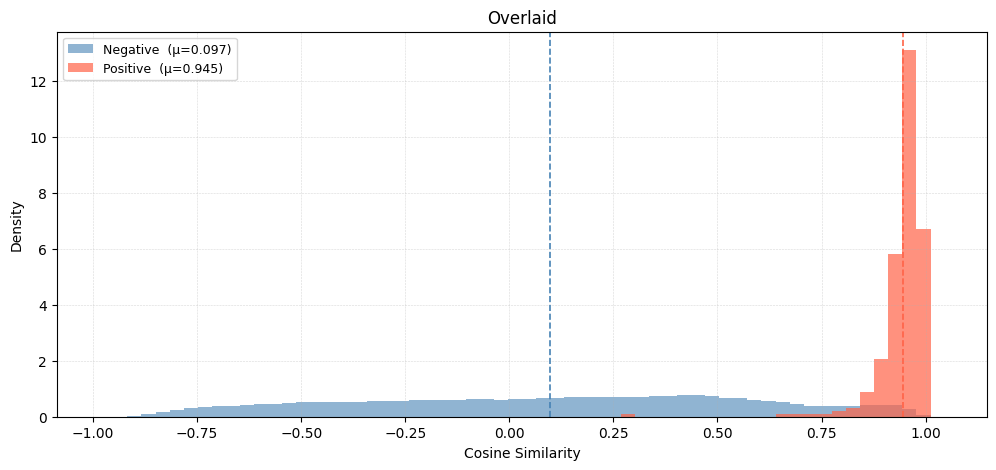

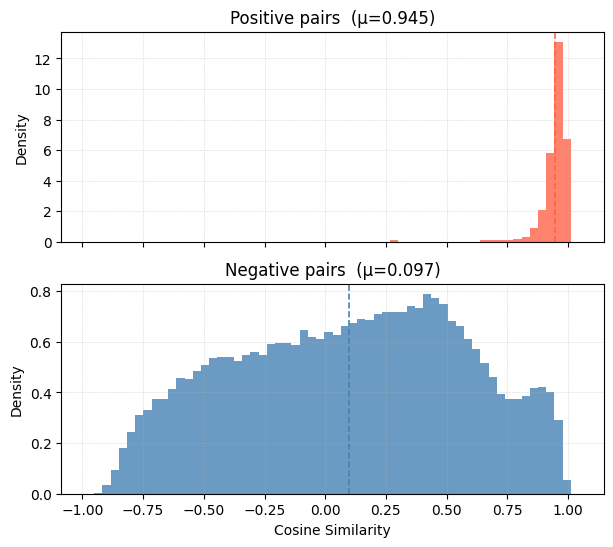

In [44]:
analyze_latent_similarity(latents_og, latents_aug);

Shape: N=600, D=32
Total variance: 9.2163e-01
Top eigenvalue fraction: 0.4227
Effective dimension (entropy): 4.93
Participation ratio: 3.60
Estimated rank: 20/32
✅ No obvious collapse


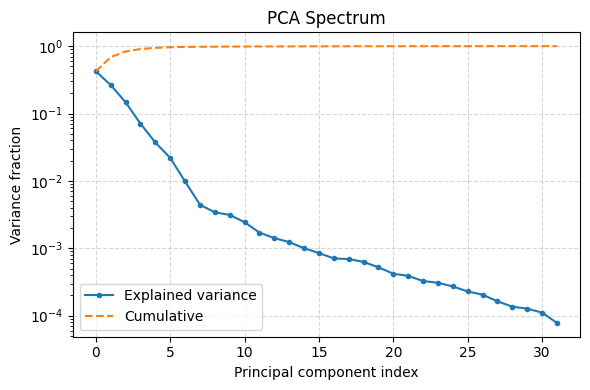

In [42]:
"""
Checking the variability in the latent embedding
"""

analyze_latent_space(np.vstack([latents_og, latents_aug]), tol=1e-3);

In [2]:
"""
Loading latents by trained PointNetEncoder model (64-dim)
"""

folder = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml_latest/pointnet_models_ttbar_dihiggs_ggf_mixed_events_no_edges/'


"""
Loading the latents of orginal events
"""

latents_ttbar_og = np.loadtxt(folder+'ttbar_original_900-1000_latents_epoch_18.txt')
latents_dihiggs_og = np.loadtxt(folder+'dihiggs_original_900-1000_latents_epoch_18.txt')
latents_ggf_og = np.loadtxt(folder+'ggf_original_900-1000_latents_epoch_18.txt')


"""
Loading the latents of augmented events
"""

latents_ttbar_aug = np.loadtxt(folder+'ttbar_augmented_900-1000_latents_epoch_18.txt')
latents_dihiggs_aug = np.loadtxt(folder+'dihiggs_augmented_900-1000_latents_epoch_18.txt')
latents_ggf_aug = np.loadtxt(folder+'ggf_augmented_900-1000_latents_epoch_18.txt')


latents_og = np.vstack([latents_ttbar_og, latents_dihiggs_og, latents_ggf_og])
latents_aug = np.vstack([latents_ttbar_aug, latents_dihiggs_aug, latents_ggf_aug])

Number of events        : 300
Positive pairs          : 300
Negative pairs (used)   : 89,700
────────────────────────────────────────
Mean cosine sim (positive) : 0.9729
Standard deviation cosine sim (positive) : 0.0101
Mean cosine sim (negative) : 0.8748
Standard deviation cosine sim (negative) : 0.1086
Separation (pos - neg)     : 0.0981


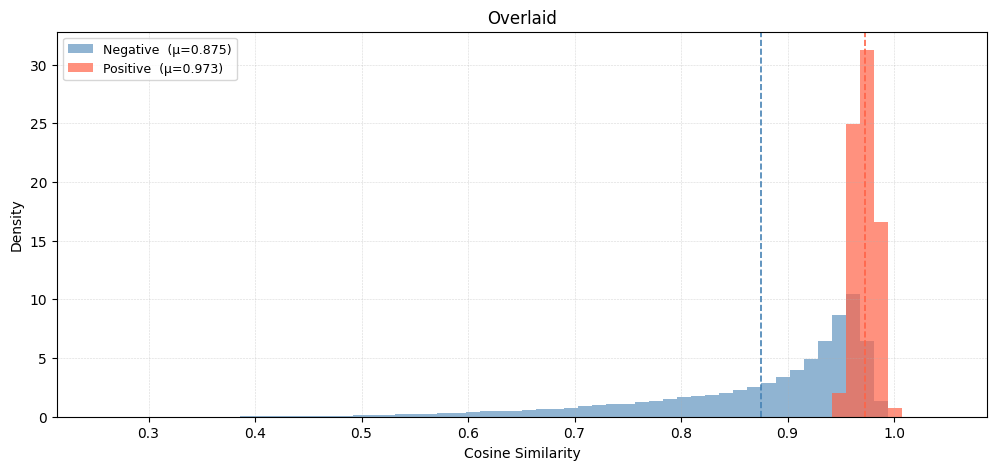

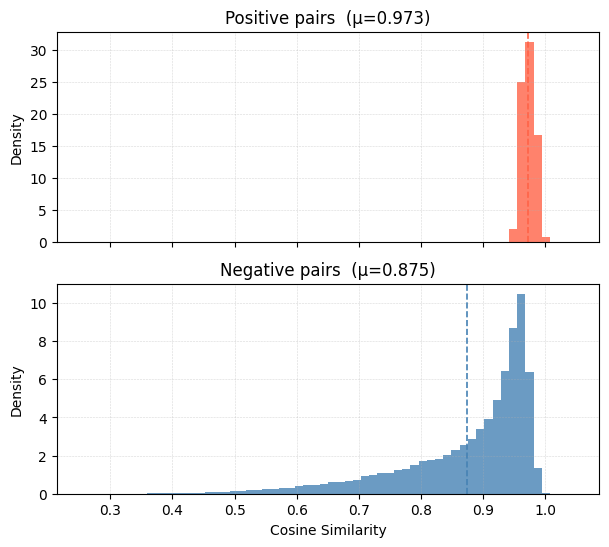

In [5]:
analyze_latent_similarity(latents_og, latents_aug);

Shape: N=600, D=64
Total variance: 7.0912e+00
Top eigenvalue fraction: 0.7677
Effective dimension (entropy): 2.91
Participation ratio: 1.67
Estimated rank: 24/64
⚠️ Possible dimensional collapse (rank significantly reduced)
⚠️ Strong anisotropy (one principal direction dominates)


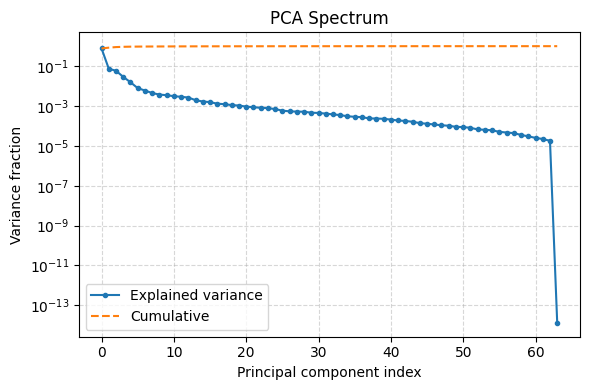

In [6]:
"""
Checking the variability in the latent embedding
"""

analyze_latent_space(np.vstack([latents_og, latents_aug]), tol=1e-3);

In [92]:
"""
Loading latents by trained GravNetEncoder model
"""

folder = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml_latest/gravnet_models_ttbar_dihiggs_ggf_mixed_events_no_edges/'


"""
Loading the latents of orginal events
"""

latents_ttbar_og = np.loadtxt(folder+'ttbar_original_900-1000_latents_epoch_18.txt')
latents_dihiggs_og = np.loadtxt(folder+'dihiggs_original_900-1000_latents_epoch_18.txt')
latents_ggf_og = np.loadtxt(folder+'ggf_original_900-1000_latents_epoch_18.txt')


"""
Loading the latents of augmented events
"""

latents_ttbar_aug = np.loadtxt(folder+'ttbar_augmented_900-1000_latents_epoch_18.txt')
latents_dihiggs_aug = np.loadtxt(folder+'dihiggs_augmented_900-1000_latents_epoch_18.txt')
latents_ggf_aug = np.loadtxt(folder+'ggf_augmented_900-1000_latents_epoch_18.txt')


latents_og = np.vstack([latents_ttbar_og, latents_dihiggs_og, latents_ggf_og])
latents_aug = np.vstack([latents_ttbar_aug, latents_dihiggs_aug, latents_ggf_aug])

Number of events        : 300
Positive pairs          : 300
Negative pairs (used)   : 89,700
────────────────────────────────────────
Mean cosine sim (positive) : 0.9861
Standard deviation cosine sim (positive) : 0.0075
Mean cosine sim (negative) : 0.6627
Standard deviation cosine sim (negative) : 0.2896
Separation (pos - neg)     : 0.3234


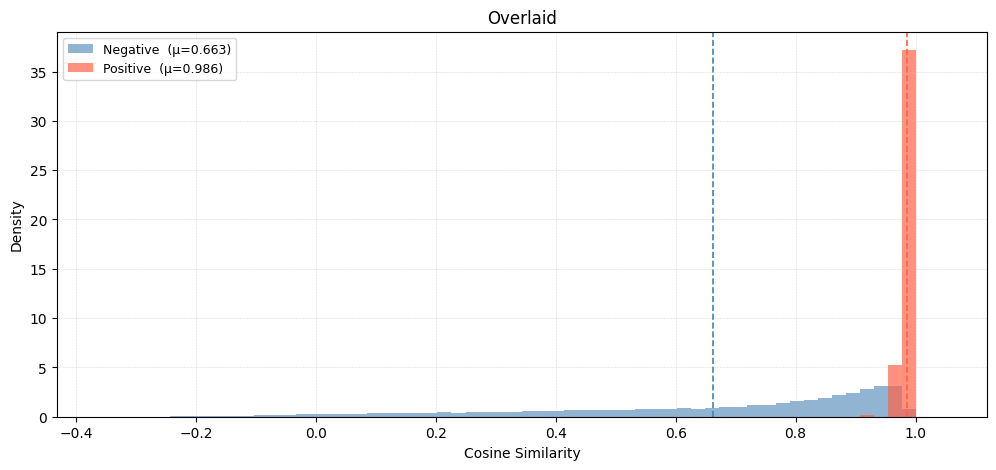

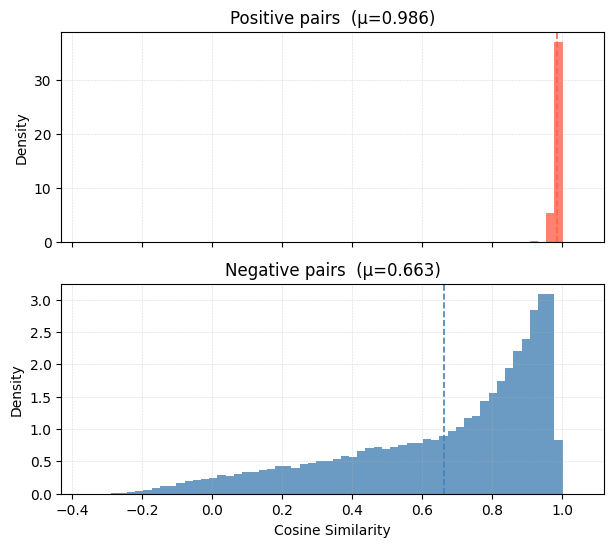

In [93]:
analyze_latent_similarity(latents_og, latents_aug);

Shape: N=600, D=64
Total variance: 3.0309e+00
Top eigenvalue fraction: 0.8022
Effective dimension (entropy): 2.21
Participation ratio: 1.52
Estimated rank: 14/64
⚠️ Possible dimensional collapse (rank significantly reduced)
⚠️ Strong anisotropy (one principal direction dominates)


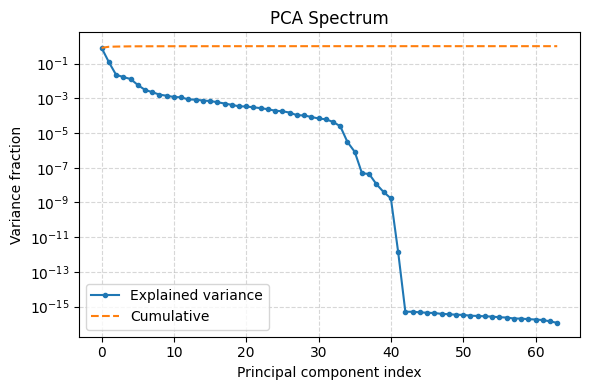

In [94]:
"""
Checking the variability in the latent embedding (64-dim)
"""

analyze_latent_space(np.vstack([latents_og, latents_aug]), tol=1e-3);

In [7]:
"""
Loading latents by trained GravNetEncoder model (32-dim)
"""

folder = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml_latest/gravnet_models_ttbar_dihiggs_ggf_mixed_events_no_edges/reduced_'


"""
Loading the latents of orginal events
"""

latents_ttbar_og = np.loadtxt(folder+'ttbar_original_900-1000_latents_epoch_18.txt')
latents_dihiggs_og = np.loadtxt(folder+'dihiggs_original_900-1000_latents_epoch_18.txt')
latents_ggf_og = np.loadtxt(folder+'ggf_original_900-1000_latents_epoch_18.txt')


"""
Loading the latents of augmented events
"""

latents_ttbar_aug = np.loadtxt(folder+'ttbar_augmented_900-1000_latents_epoch_18.txt')
latents_dihiggs_aug = np.loadtxt(folder+'dihiggs_augmented_900-1000_latents_epoch_18.txt')
latents_ggf_aug = np.loadtxt(folder+'ggf_augmented_900-1000_latents_epoch_18.txt')


latents_og = np.vstack([latents_ttbar_og, latents_dihiggs_og, latents_ggf_og])
latents_aug = np.vstack([latents_ttbar_aug, latents_dihiggs_aug, latents_ggf_aug])

Number of events        : 300
Positive pairs          : 300
Negative pairs (used)   : 89,700
────────────────────────────────────────
Mean cosine sim (positive) : 0.9311
Standard deviation cosine sim (positive) : 0.0761
Mean cosine sim (negative) : 0.0469
Standard deviation cosine sim (negative) : 0.3564
Separation (pos - neg)     : 0.8842


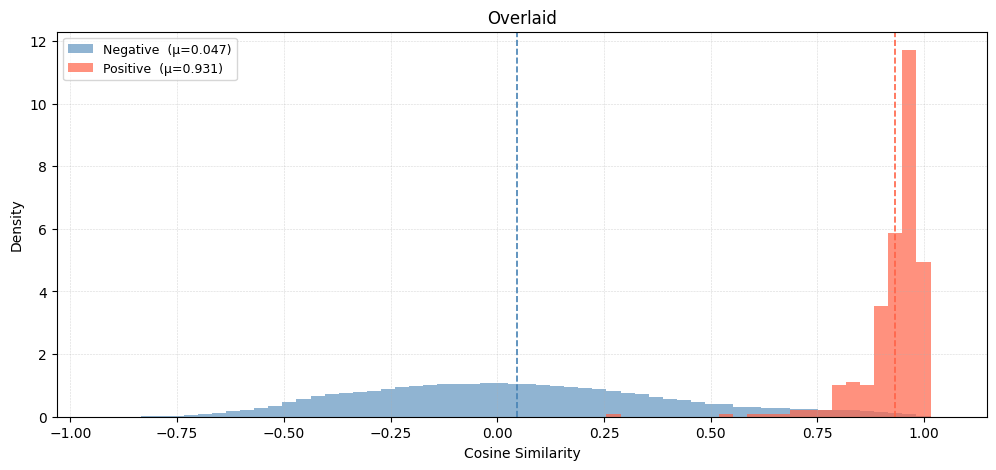

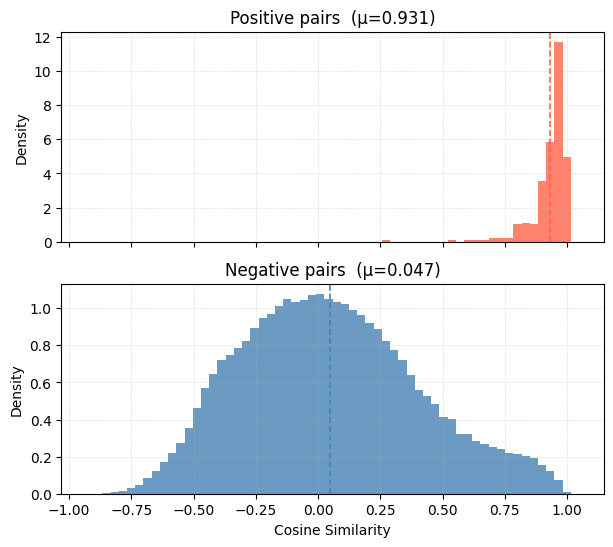

In [8]:
analyze_latent_similarity(latents_og, latents_aug);

Shape: N=600, D=32
Total variance: 1.0987e+00
Top eigenvalue fraction: 0.2558
Effective dimension (entropy): 8.68
Participation ratio: 6.58
Estimated rank: 29/32
✅ No obvious collapse


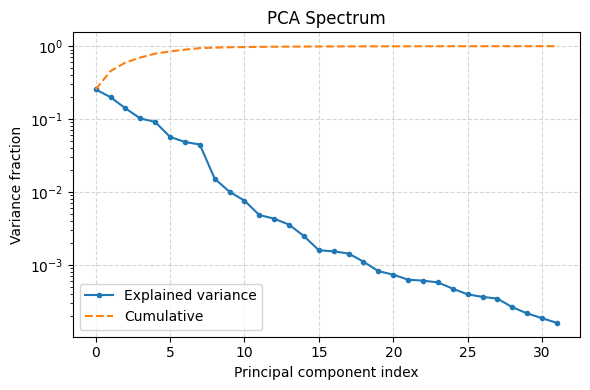

In [9]:
analyze_latent_space(np.vstack([latents_og, latents_aug]), tol=1e-3);

# Linear probe regression

In [17]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error


def linear_probe_regression(
    latents: np.ndarray,
    targets: np.ndarray,
    test_size: float = 0.2,
    random_state: int = 42,
    scale: bool = True,
    alpha: float = 1.0,
    verbose: bool = True,
) -> dict:
    """
    Trains a Ridge regression linear probe on latent representations
    and reports R² accuracy.

    Args:
        latents:      Array of shape (N, D) — N samples, D-dimensional latents.
        targets:      Array of shape (N,) with continuous regression targets.
        test_size:    Fraction of data held out for evaluation.
        random_state: Seed for reproducibility.
        scale:        Whether to standardize latents before probing.
        alpha:        Ridge regularization strength (higher = more regularization).
        verbose:      Whether to print a summary report.

    Returns:
        dict with keys:
            - train_r2  : R² on the training split
            - test_r2   : R² on the held-out test split
            - train_mse : MSE on the training split
            - test_mse  : MSE on the held-out test split
            - probe     : the fitted Ridge model
            - scaler    : the fitted StandardScaler (or None)
    """
    X_train, X_test, y_train, y_test = train_test_split(
        latents, targets, test_size=test_size, random_state=random_state
    )

    scaler = None
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

    probe = Ridge(alpha=alpha, random_state=random_state)
    probe.fit(X_train, y_train)

    train_preds = probe.predict(X_train)
    test_preds  = probe.predict(X_test)

    train_r2  = r2_score(y_train, train_preds)
    test_r2   = r2_score(y_test,  test_preds)
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse  = mean_squared_error(y_test,  test_preds)

    if verbose:
        print(f"Train R²  : {train_r2:.4f}    Train MSE : {train_mse:.4f}")
        print(f"Test  R²  : {test_r2:.4f}    Test  MSE : {test_mse:.4f}")

    return {
        "train_r2" : train_r2,
        "test_r2"  : test_r2,
        "train_mse": train_mse,
        "test_mse" : test_mse,
        "probe"    : probe,
        "scaler"   : scaler,
    }





import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_validate, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


def linear_probe_regression2(
    latents: np.ndarray,
    targets: np.ndarray,
    n_splits: int = 5,
    random_state: int = 42,
    scale: bool = True,
    alphas: tuple = (0.01, 0.1, 1.0, 10.0, 100.0, 1000.0),
    verbose: bool = True,
) -> dict:
    """
    Trains a Ridge regression linear probe using k-fold cross-validation
    with automatic alpha selection via RidgeCV.

    Args:
        latents:      (N, D) array of latent representations.
        targets:      (N,)  array of continuous regression targets.
        n_splits:     Number of CV folds (default 5). Use 10 for more stability.
        random_state: Seed for the KFold splitter.
        scale:        Whether to standardize latents inside each fold.
        alphas:       Grid of regularization strengths searched by RidgeCV.
        verbose:      Whether to print a summary.

    Returns:
        dict with keys:
            - cv_r2_mean     : mean R² across folds
            - cv_r2_std      : std  R² across folds  ← stability indicator
            - cv_mse_mean    : mean MSE across folds
            - cv_mse_std     : std  MSE across folds
            - cv_r2_scores   : per-fold R² array
            - cv_mse_scores  : per-fold MSE array
            - best_alpha     : alpha chosen by the last fold's RidgeCV
            - probe          : the pipeline fitted on ALL data (for inference)
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Pipeline ensures scaler is fit only on train fold → no leakage
    steps = []
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("ridge", RidgeCV(alphas=alphas, fit_intercept=True)))
    pipe = Pipeline(steps)

    cv_results = cross_validate(
        pipe, latents, targets,
        cv=kf,
        scoring={"r2": "r2", "mse": "neg_mean_squared_error"},
        return_train_score=True,
    )

    cv_r2_scores     =  cv_results["test_r2"]
    cv_mse_scores    = -cv_results["test_mse"]        # ← was "test_neg_mean_squared_error"
    train_r2_scores  =  cv_results["train_r2"]
    train_mse_scores = -cv_results["train_mse"] 
    # Refit on full data to expose the chosen alpha + ready-to-use probe
    pipe.fit(latents, targets)
    best_alpha = pipe.named_steps["ridge"].alpha_

    if verbose:
        print(f"{'Fold':<6} {'Train R²':>10} {'Test R²':>10} {'Test MSE':>12}")
        print("-" * 42)
        for i, (tr2, vr2, vmse) in enumerate(
            zip(train_r2_scores, cv_r2_scores, cv_mse_scores), 1
        ):
            print(f"{i:<6} {tr2:>10.4f} {vr2:>10.4f} {vmse:>12.4f}")
        print("-" * 42)
        print(f"{'Mean':<6} {train_r2_scores.mean():>10.4f} "
              f"{cv_r2_scores.mean():>10.4f} {cv_mse_scores.mean():>12.4f}")
        print(f"{'Std':<6} {train_r2_scores.std():>10.4f} "
              f"{cv_r2_scores.std():>10.4f} {cv_mse_scores.std():>12.4f}")
        print(f"\nBest alpha (last fold): {best_alpha}")

    return {
        "cv_r2_mean"   : cv_r2_scores.mean(),
        "cv_r2_std"    : cv_r2_scores.std(),
        "cv_mse_mean"  : cv_mse_scores.mean(),
        "cv_mse_std"   : cv_mse_scores.std(),
        "cv_r2_scores" : cv_r2_scores,
        "cv_mse_scores": cv_mse_scores,
        "best_alpha"   : best_alpha,
        "probe"        : pipe,
    }

In [22]:

"""
Loading ColliderML data

"""

from colliderml.core import load_tables, collect_tables


## ttbar data
cfg1 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "ttbar",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": 1000,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables1 = load_tables(cfg1)
frames1 = collect_tables(tables1)

calo_hits1 = frames1["calo_hits"][900:1000]

dataset_test_ttbar = ColliderMLHits(calo_hits1, "val", shuffle_files=False, train_fraction=0.0)


from colliderml.core import load_tables, collect_tables
## dihiggs data
cfg2 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "dihiggs",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": 1000,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables2 = load_tables(cfg2)
frames2 = collect_tables(tables2)

calo_hits2 = frames2["calo_hits"][900:1000]

dataset_test_dihiggs = ColliderMLHits(calo_hits2, "val", shuffle_files=False, train_fraction=0.0)


## ggf data
cfg3 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "ggf",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": 1000,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables3 = load_tables(cfg3)
frames3 = collect_tables(tables3)

calo_hits3 = frames3["calo_hits"][900:1000]

dataset_test_ggf = ColliderMLHits(calo_hits3, "val", shuffle_files=False, train_fraction=0.0)


for data in dataset_test_ggf:

    print(data['calo_hit_features'][:,0])

    break

[-314.15973  158.1      147.9     ... -412.0863  -191.3657   194.15135]


In [23]:
num_hits_ttbar = []
num_hits_ggf = []
num_hits_dihiggs = []


for data in dataset_test_ttbar:

   num_hits_ttbar.append(len(data['calo_hit_features'][:,0]))

for data in dataset_test_ggf:
    
   num_hits_ggf.append(len(data['calo_hit_features'][:,0]))

for data in dataset_test_dihiggs:

   num_hits_dihiggs.append(len(data['calo_hit_features'][:,0]))

    #break
    
num_hits_ttbar = np.array(num_hits_ttbar)
num_hits_ggf = np.array(num_hits_ggf)
num_hits_dihiggs = np.array(num_hits_dihiggs)

num_hits_ttbar_ = (num_hits_ttbar - np.mean(num_hits_ttbar))/np.std(num_hits_ttbar)
num_hits_ggf_ = (num_hits_ggf - np.mean(num_hits_ggf))/np.std(num_hits_ggf)
num_hits_dihiggs_ = (num_hits_dihiggs - np.mean(num_hits_dihiggs))/np.std(num_hits_dihiggs)


e_hits_ttbar = []
e_hits_ggf = []
e_hits_dihiggs = []


for data in dataset_test_ttbar:

   e_hits_ttbar.append(np.sum(np.exp(data['calo_hit_features'][:,3])))

for data in dataset_test_ggf:
    
   e_hits_ggf.append(np.sum(np.exp(data['calo_hit_features'][:,3])))

for data in dataset_test_dihiggs:

   e_hits_dihiggs.append(np.sum(np.exp(data['calo_hit_features'][:,3])))

    #break
    
e_hits_ttbar = np.array(e_hits_ttbar)
e_hits_ggf = np.array(e_hits_ggf)
e_hits_dihiggs = np.array(e_hits_dihiggs)

e_hits_ttbar_ = (e_hits_ttbar - np.mean(e_hits_ttbar))/np.std(e_hits_ttbar)
e_hits_ggf_ = (e_hits_ggf - np.mean(e_hits_ggf))/np.std(e_hits_ggf)
e_hits_dihiggs_ = (e_hits_dihiggs - np.mean(e_hits_dihiggs))/np.std(e_hits_dihiggs)



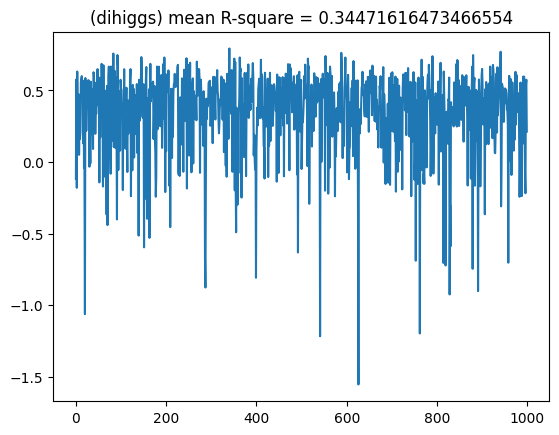

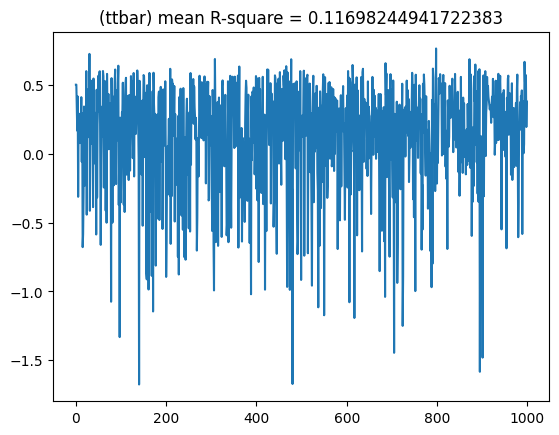

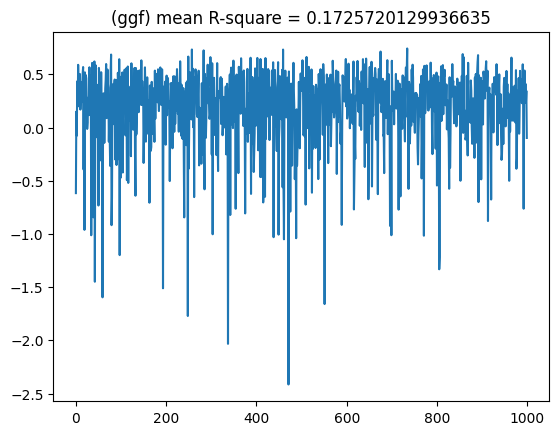

In [127]:

"""
Loading latents by trained PointNetEncoder model
"""

folder = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml_latest/pointnet_models_ttbar_dihiggs_ggf_mixed_events_no_edges/'


"""
Loading the latents of orginal events
"""

latents_ttbar_og = np.loadtxt(folder+'ttbar_original_900-1000_latents_epoch_18.txt')
latents_dihiggs_og = np.loadtxt(folder+'dihiggs_original_900-1000_latents_epoch_18.txt')
latents_ggf_og = np.loadtxt(folder+'ggf_original_900-1000_latents_epoch_18.txt')


"""
Loading the latents of augmented events
"""

latents_ttbar_aug = np.loadtxt(folder+'ttbar_augmented_900-1000_latents_epoch_18.txt')
latents_dihiggs_aug = np.loadtxt(folder+'dihiggs_augmented_900-1000_latents_epoch_18.txt')
latents_ggf_aug = np.loadtxt(folder+'ggf_augmented_900-1000_latents_epoch_18.txt')



#linear_probe_regression(latents_dihiggs_og, num_hits_dihiggs_, random_state=47)
#linear_probe_regression(latents_dihiggs_og, e_hits_dihiggs_, random_state=47)


data = latents_dihiggs_og
target = e_hits_dihiggs_

r2 = []

for i in range(1000):

    r2.append(linear_probe_regression(data, target, random_state=i, verbose=False)['test_r2'])

plt.figure()

plt.plot(np.arange(0,1000,1), r2)

plt.title('(dihiggs) mean R-square = {}'.format(sum(r2)/len(r2)))

plt.show()


data = latents_ttbar_og
target = e_hits_ttbar_

r2 = []

for i in range(1000):

    r2.append(linear_probe_regression(data, target, random_state=i, verbose=False)['test_r2'])

plt.figure()

plt.plot(np.arange(0,1000,1), r2)

plt.title('(ttbar) mean R-square = {}'.format(sum(r2)/len(r2)))

plt.show()


data = latents_ggf_og
target = e_hits_ggf_

r2 = []

for i in range(1000):

    r2.append(linear_probe_regression(data, target, random_state=i, verbose=False)['test_r2'])

plt.figure()

plt.plot(np.arange(0,1000,1), r2)

plt.title('(ggf) mean R-square = {}'.format(sum(r2)/len(r2)))

plt.show()
    
    

## Single kind of event training with different augmentations

After projection statistics:
Number of events        : 100
Positive pairs          : 100
Negative pairs (used)   : 9,900
────────────────────────────────────────
Mean cosine sim (positive) : 0.9619
Standard deviation cosine sim (positive) : 0.0412
Mean cosine sim (negative) : 0.0737
Standard deviation cosine sim (negative) : 0.4072
Separation (pos - neg)     : 0.8882
Shape: N=200, D=32
Total variance: 7.1280e-01
Top eigenvalue fraction: 0.3378
Effective dimension (entropy): 6.63
Participation ratio: 4.68
Estimated rank: 26/32
95% variance is in 8/32 dimensions
✅ No obvious collapse


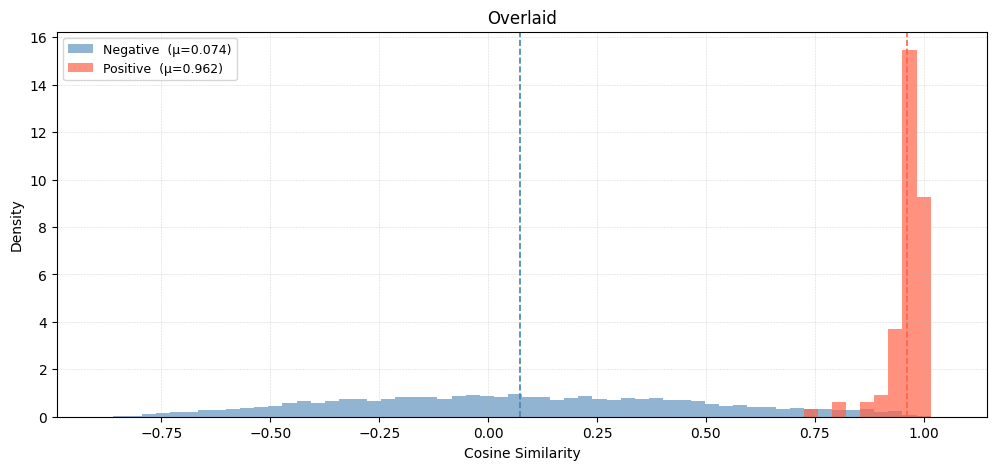

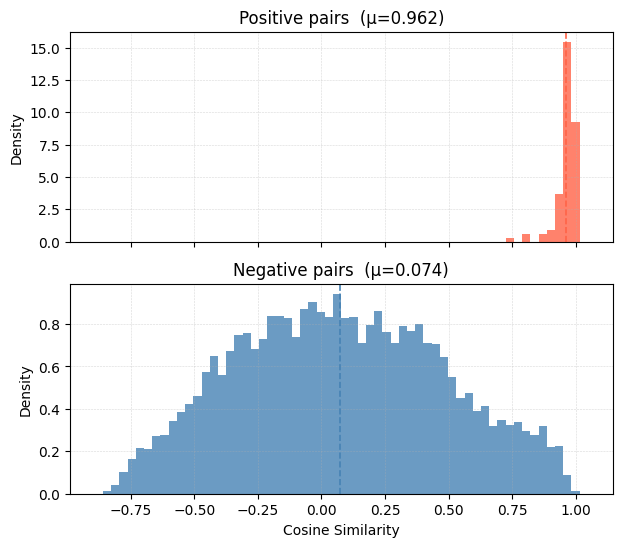

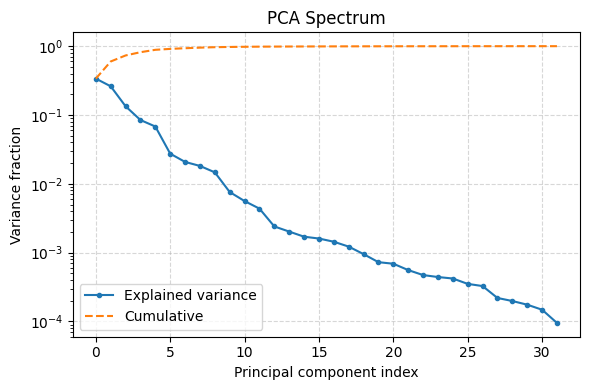

In [24]:

"""
Specifying the latents
"""

split = 'dihiggs'
rot = 2*np.pi
energy_noise = 0.05

folder = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml_latest/gravnet_models_{}_rot_{:.2f}_noise_{:.2f}/'.format(split, rot, energy_noise)

latents_og_w_proj = np.loadtxt(folder+'with_projection_'+'dihiggs_original_900-1000_latents_epoch_20.txt')
latents_aug_w_proj = np.loadtxt(folder+'with_projection_'+'dihiggs_augmented_900-1000_latents_epoch_20.txt')


latents_og_wo_proj = np.loadtxt(folder+'without_projection_'+'dihiggs_original_900-1000_latents_epoch_20.txt')
latents_aug_wo_proj = np.loadtxt(folder+'without_projection_'+'dihiggs_augmented_900-1000_latents_epoch_20.txt')



print("After projection statistics:")


analyze_latent_similarity(latents_og_w_proj, latents_aug_w_proj);


#print("Before projection statistics:")


#analyze_latent_similarity(latents_og_wo_proj, latents_aug_wo_proj);

analyze_latent_space(np.vstack([latents_og_w_proj, latents_aug_w_proj]), tol=1e-3);







Before projection statistics:
Number of events        : 100
Positive pairs          : 100
Negative pairs (used)   : 9,900
────────────────────────────────────────
Mean cosine sim (positive) : 0.9955
Standard deviation cosine sim (positive) : 0.0037
Mean cosine sim (negative) : 0.6766
Standard deviation cosine sim (negative) : 0.2960
Separation (pos - neg)     : 0.3189
Shape: N=200, D=64
Total variance: 2.6395e+00
Top eigenvalue fraction: 0.8384
Effective dimension (entropy): 1.93
Participation ratio: 1.40
Estimated rank: 9/64
95% variance is in 3/64 dimensions
⚠️ Possible dimensional collapse (rank significantly reduced)
⚠️ Strong anisotropy (one principal direction dominates)


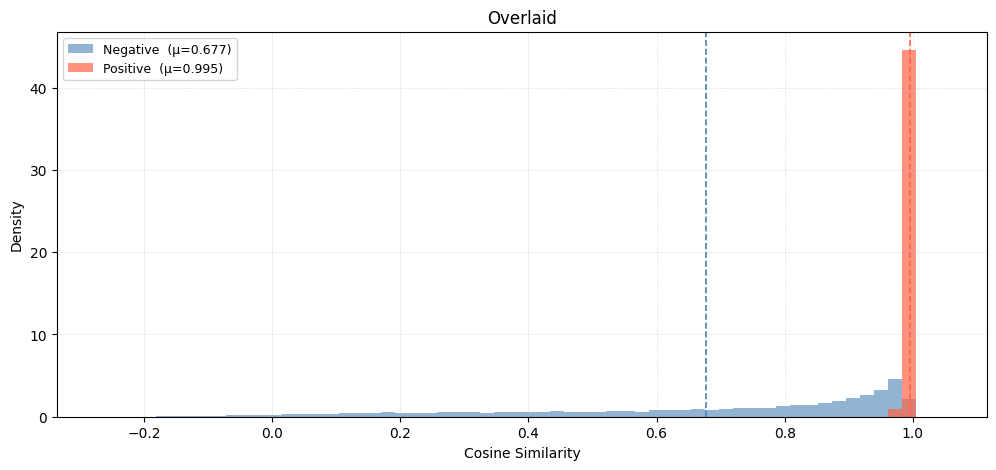

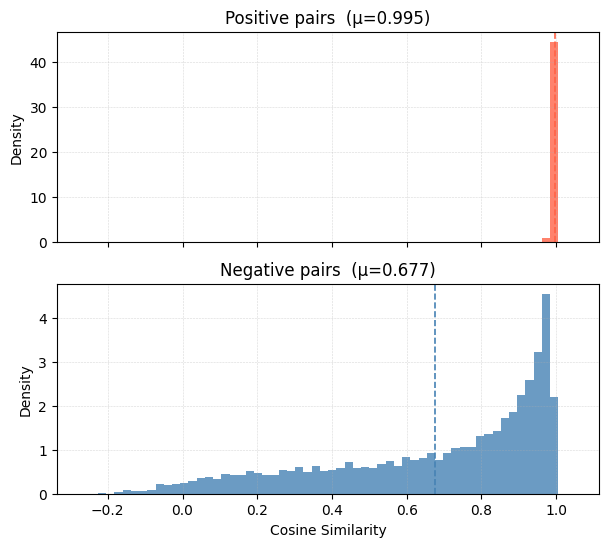

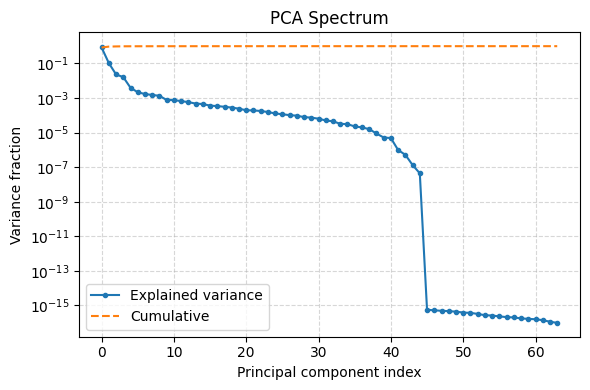

In [25]:
print("Before projection statistics:")


analyze_latent_similarity(latents_og_wo_proj, latents_aug_wo_proj);

analyze_latent_space(np.vstack([latents_og_wo_proj, latents_aug_wo_proj]), tol=1e-3);


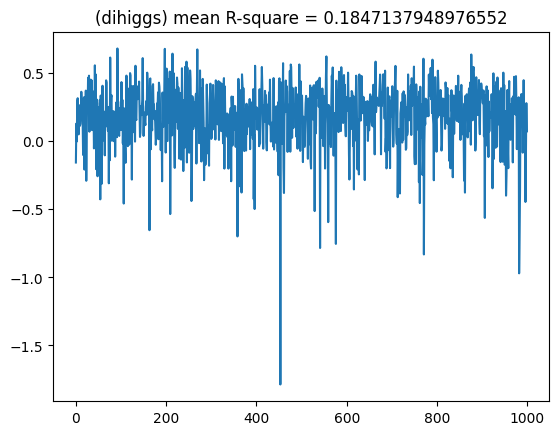

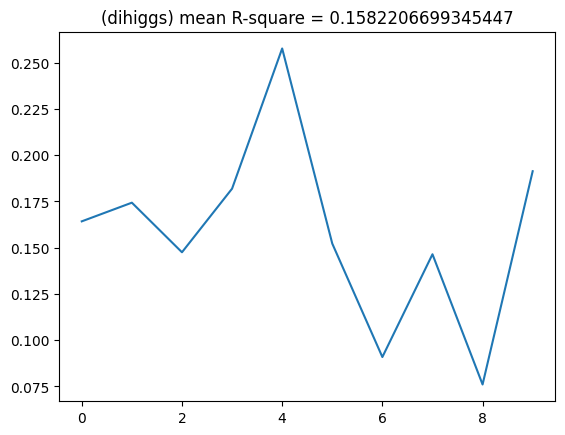

In [40]:
data = latents_og_wo_proj
target = num_hits_dihiggs_

r2 = []

for i in range(1000):

    r2.append(linear_probe_regression(data, target, random_state=i, verbose=False)['test_r2'])

plt.figure()

plt.plot(np.arange(0,1000,1), r2)

plt.title('(dihiggs) mean R-square = {}'.format(sum(r2)/len(r2)))

plt.show()



data = latents_og_wo_proj
target = num_hits_dihiggs_

r2 = []

for i in range(10):

    r2.append(linear_probe_regression2(data, target, random_state=i, verbose=False)['cv_r2_mean'])

plt.figure()

plt.plot(np.arange(0,10,1), r2)

plt.title('(dihiggs) mean R-square = {}'.format(sum(r2)/len(r2)))

plt.show()

After projection statistics:
Number of events        : 100
Positive pairs          : 100
Negative pairs (used)   : 9,900
────────────────────────────────────────
Mean cosine sim (positive) : 0.9470
Standard deviation cosine sim (positive) : 0.0414
Mean cosine sim (negative) : 0.0652
Standard deviation cosine sim (negative) : 0.3336
Separation (pos - neg)     : 0.8817
Shape: N=200, D=32
Total variance: 8.2023e-01
Top eigenvalue fraction: 0.2236
Effective dimension (entropy): 9.43
Participation ratio: 7.14
Estimated rank: 30/32
95% variance is in 10/32 dimensions
✅ No obvious collapse


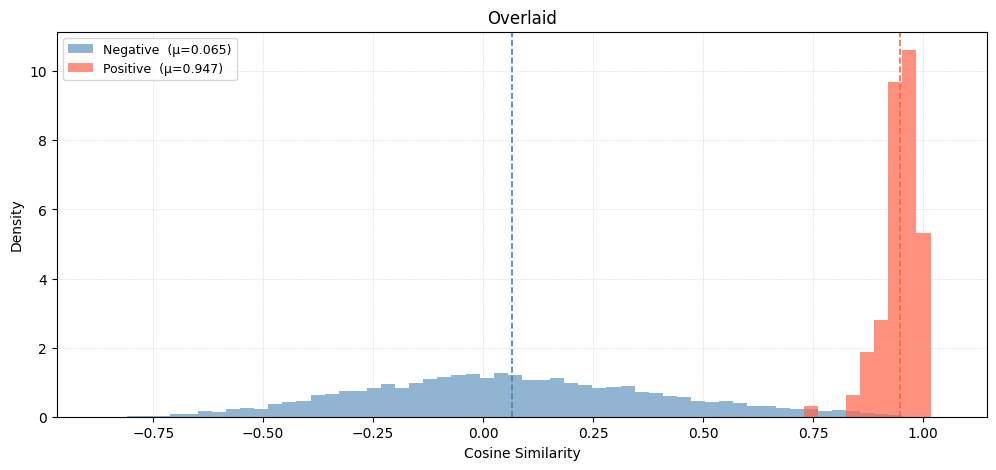

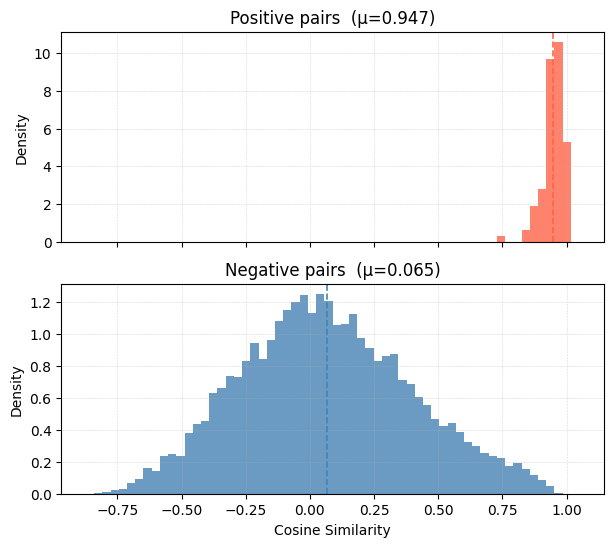

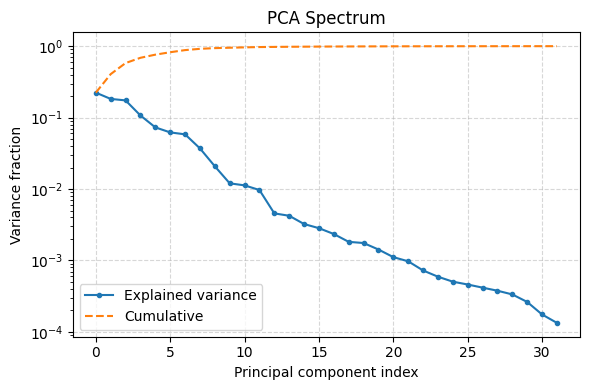

In [20]:
split = 'dihiggs'
rot = 2*np.pi
energy_noise = 1e-17

folder = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml_latest/gravnet_models_{}_rot_{:.2f}_noise_{:.2f}/'.format(split, rot, energy_noise)

latents_og_w_proj = np.loadtxt(folder+'with_projection_'+'dihiggs_original_900-1000_latents_epoch_20.txt')
latents_aug_w_proj = np.loadtxt(folder+'with_projection_'+'dihiggs_augmented_900-1000_latents_epoch_20.txt')


latents_og_wo_proj = np.loadtxt(folder+'without_projection_'+'dihiggs_original_900-1000_latents_epoch_20.txt')
latents_aug_wo_proj = np.loadtxt(folder+'without_projection_'+'dihiggs_augmented_900-1000_latents_epoch_20.txt')



print("After projection statistics:")


analyze_latent_similarity(latents_og_w_proj, latents_aug_w_proj);


#print("Before projection statistics:")


#analyze_latent_similarity(latents_og_wo_proj, latents_aug_wo_proj);

analyze_latent_space(np.vstack([latents_og_w_proj, latents_aug_w_proj]), tol=1e-3);


Before projection statistics:
Number of events        : 100
Positive pairs          : 100
Negative pairs (used)   : 9,900
────────────────────────────────────────
Mean cosine sim (positive) : 0.9943
Standard deviation cosine sim (positive) : 0.0041
Mean cosine sim (negative) : 0.7089
Standard deviation cosine sim (negative) : 0.2389
Separation (pos - neg)     : 0.2854
Shape: N=200, D=64
Total variance: 2.8958e+00
Top eigenvalue fraction: 0.7309
Effective dimension (entropy): 2.60
Participation ratio: 1.77
Estimated rank: 14/64
95% variance is in 4/64 dimensions
⚠️ Possible dimensional collapse (rank significantly reduced)
⚠️ Strong anisotropy (one principal direction dominates)


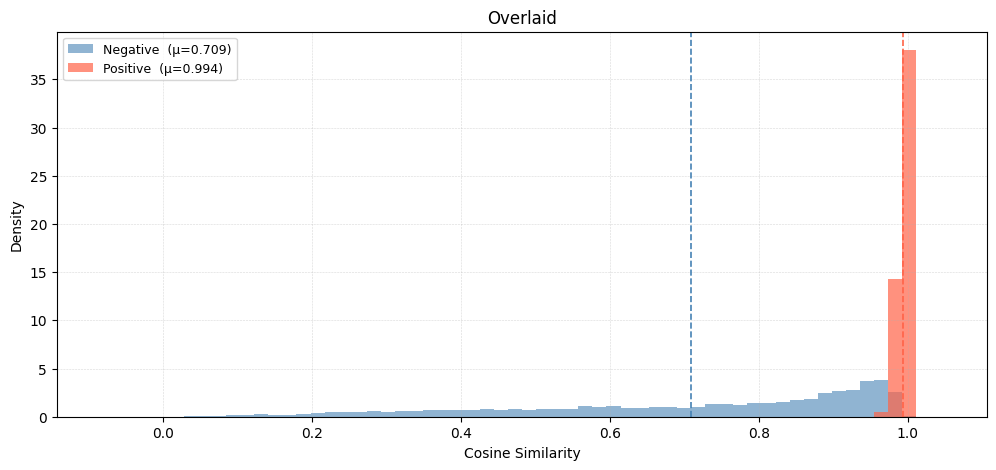

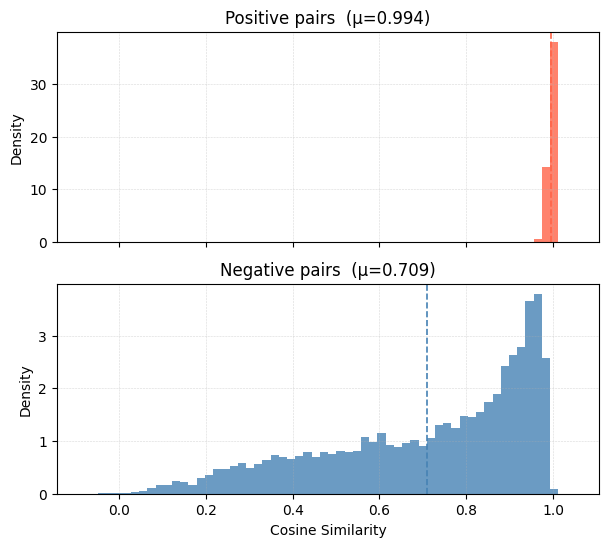

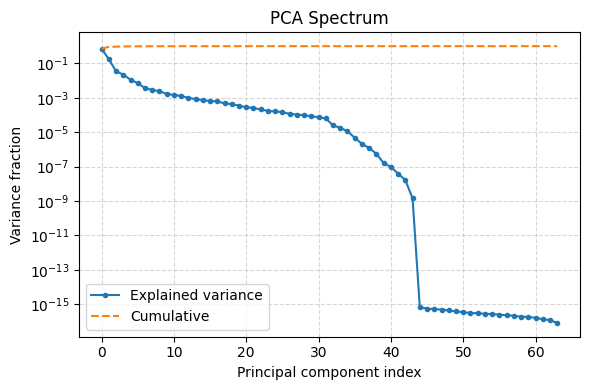

In [21]:
print("Before projection statistics:")


analyze_latent_similarity(latents_og_wo_proj, latents_aug_wo_proj);

analyze_latent_space(np.vstack([latents_og_wo_proj, latents_aug_wo_proj]), tol=1e-3);


After projection statistics:
Number of events        : 100
Positive pairs          : 100
Negative pairs (used)   : 9,900
────────────────────────────────────────
Mean cosine sim (positive) : 0.3115
Standard deviation cosine sim (positive) : 0.3174
Mean cosine sim (negative) : 0.0598
Standard deviation cosine sim (negative) : 0.2513
Separation (pos - neg)     : 0.2518
Shape: N=200, D=32
Total variance: 1.6691e+00
Top eigenvalue fraction: 0.1287
Effective dimension (entropy): 18.06
Participation ratio: 14.09
Estimated rank: 32/32
95% variance is in 20/32 dimensions
✅ No obvious collapse


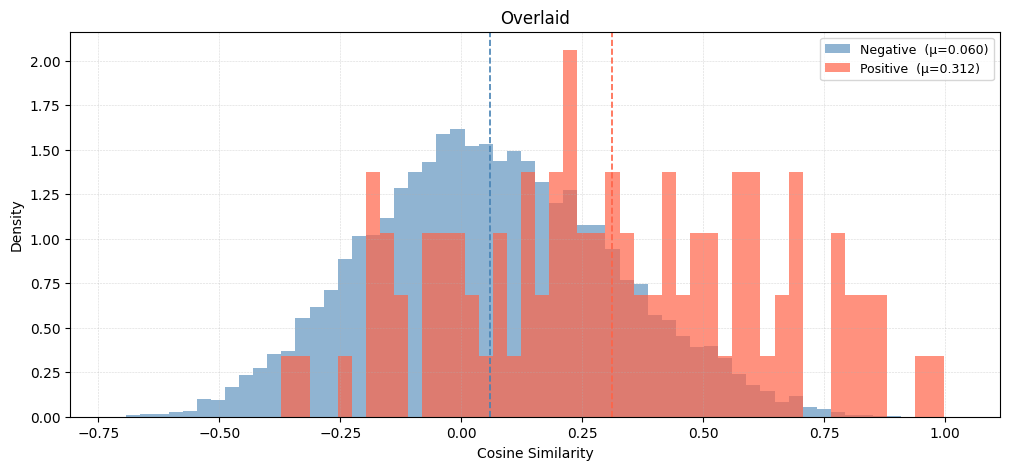

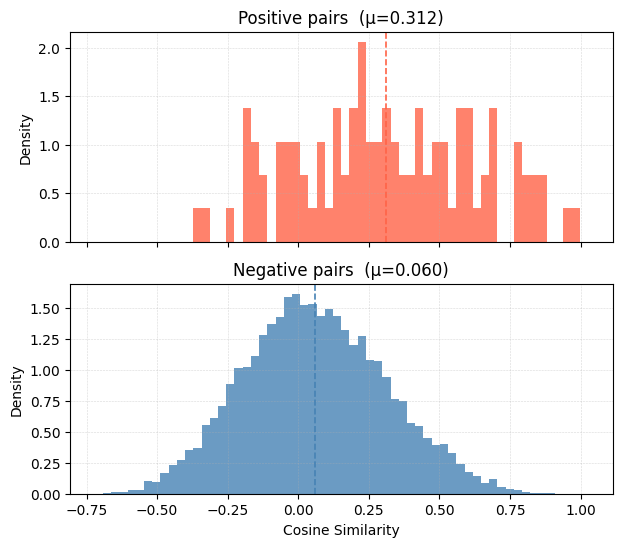

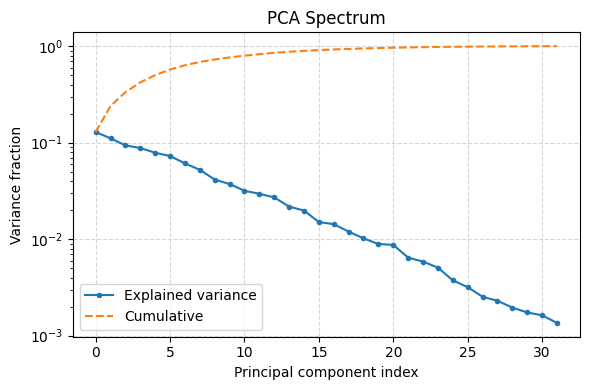

In [47]:
split = 'dihiggs'
rot = 1e-17
energy_noise = 0.05

folder = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml_latest/gravnet_models_{}_rot_{:.2f}_noise_{:.2f}/'.format(split, rot, energy_noise)

latents_og_w_proj = np.loadtxt(folder+'with_projection_'+'dihiggs_original_900-1000_latents_epoch_20.txt')
latents_aug_w_proj = np.loadtxt(folder+'with_projection_'+'dihiggs_augmented_900-1000_latents_epoch_20.txt')
latents_aug_no_rot_w_proj = np.loadtxt(folder+'with_projection_'+'dihiggs_augmented_no_rot_900-1000_latents_epoch_20.txt')


latents_og_wo_proj = np.loadtxt(folder+'without_projection_'+'dihiggs_original_900-1000_latents_epoch_20.txt')
latents_aug_wo_proj = np.loadtxt(folder+'without_projection_'+'dihiggs_augmented_900-1000_latents_epoch_20.txt')
latents_aug_no_rot_wo_proj = np.loadtxt(folder+'without_projection_'+'dihiggs_augmented_no_rot_900-1000_latents_epoch_20.txt')



print("After projection statistics:")


analyze_latent_similarity(latents_og_w_proj, latents_aug_w_proj);


#print("Before projection statistics:")


#analyze_latent_similarity(latents_og_wo_proj, latents_aug_wo_proj);

analyze_latent_space(np.vstack([latents_og_w_proj, latents_aug_w_proj]), tol=1e-3);


Before projection statistics:
Number of events        : 100
Positive pairs          : 100
Negative pairs (used)   : 9,900
────────────────────────────────────────
Mean cosine sim (positive) : 0.7653
Standard deviation cosine sim (positive) : 0.1283
Mean cosine sim (negative) : 0.5953
Standard deviation cosine sim (negative) : 0.1649
Separation (pos - neg)     : 0.1699
Shape: N=200, D=64
Total variance: 2.6419e+00
Top eigenvalue fraction: 0.2861
Effective dimension (entropy): 11.98
Participation ratio: 7.15
Estimated rank: 39/64
95% variance is in 17/64 dimensions
✅ No obvious collapse


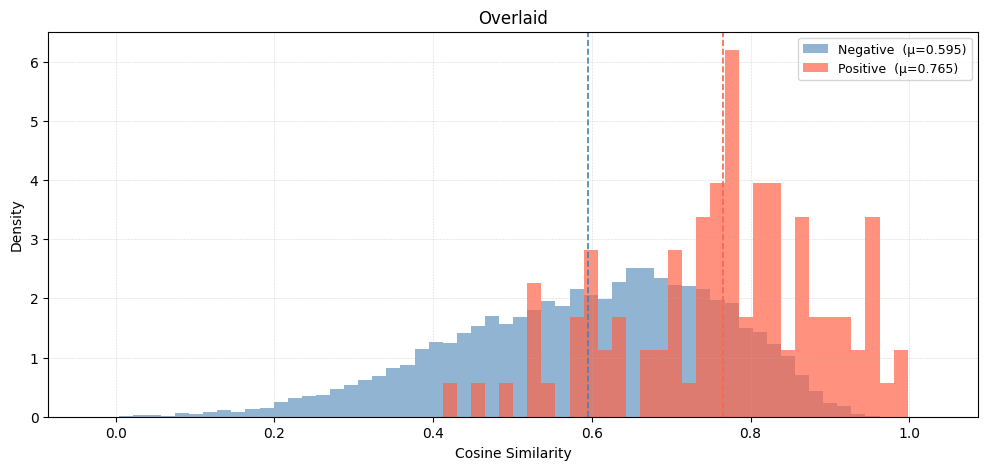

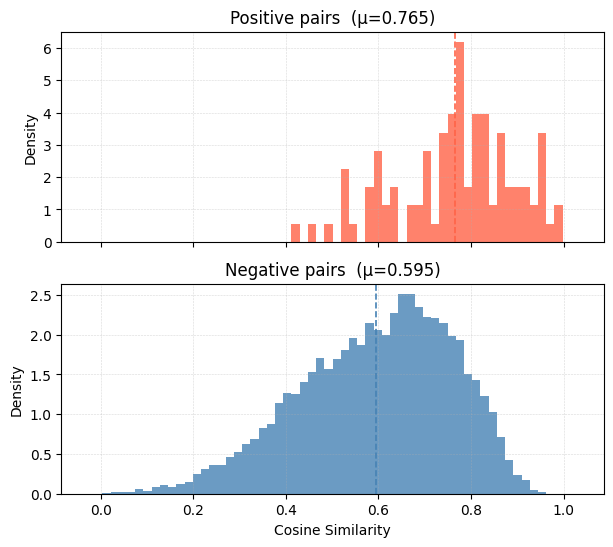

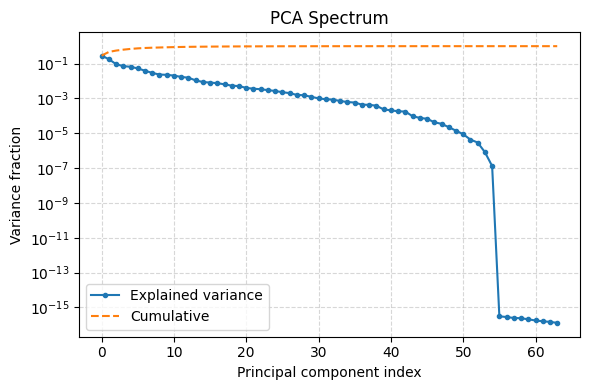

In [44]:
print("Before projection statistics:")


analyze_latent_similarity(latents_og_wo_proj, latents_aug_wo_proj);

analyze_latent_space(np.vstack([latents_og_wo_proj, latents_aug_wo_proj]), tol=1e-3);


Number of events        : 100
Positive pairs          : 100
Negative pairs (used)   : 9,900
────────────────────────────────────────
Mean cosine sim (positive) : 0.9678
Standard deviation cosine sim (positive) : 0.0316
Mean cosine sim (negative) : 0.0689
Standard deviation cosine sim (negative) : 0.2532
Separation (pos - neg)     : 0.8989
Shape: N=200, D=32
Total variance: 1.6304e+00
Top eigenvalue fraction: 0.1511
Effective dimension (entropy): 17.00
Participation ratio: 12.92
Estimated rank: 32/32
95% variance is in 19/32 dimensions
✅ No obvious collapse


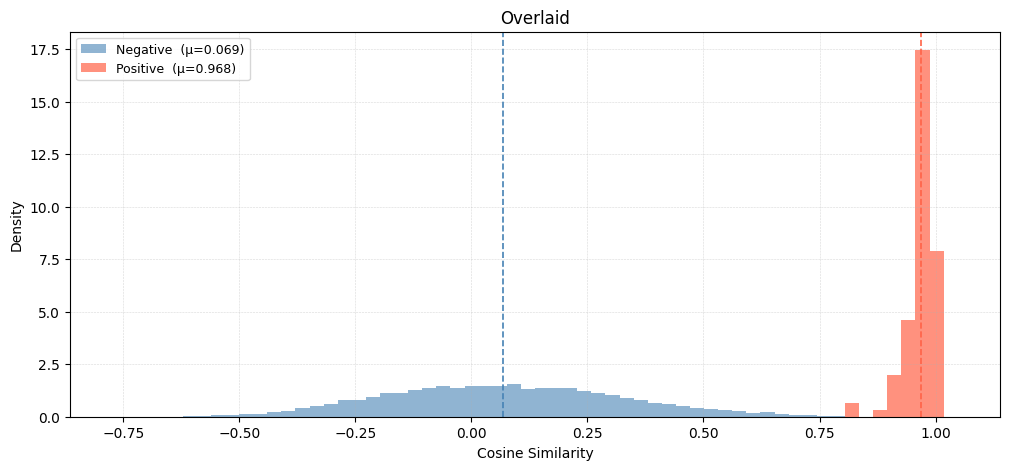

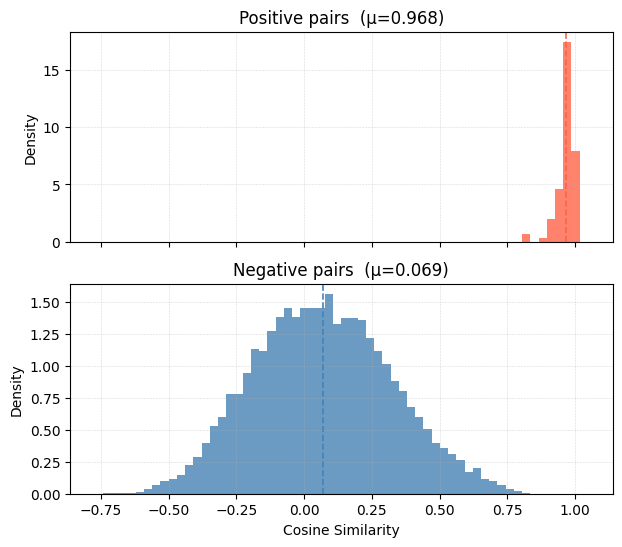

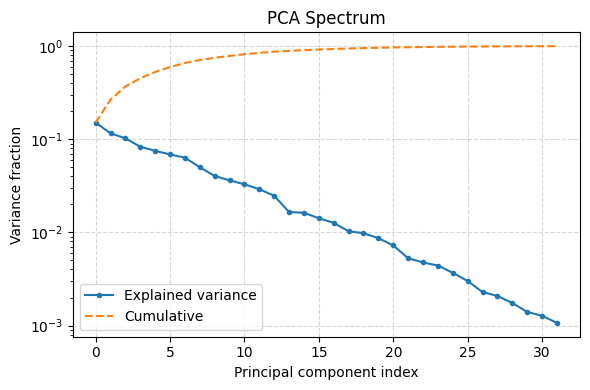

In [51]:
analyze_latent_similarity(latents_og_w_proj, latents_aug_no_rot_w_proj);


analyze_latent_space(np.vstack([latents_og_w_proj, latents_aug_no_rot_w_proj]), tol=1e-3);


Before projection statistics:
Number of events        : 100
Positive pairs          : 100
Negative pairs (used)   : 9,900
────────────────────────────────────────
Mean cosine sim (positive) : 0.9917
Standard deviation cosine sim (positive) : 0.0059
Mean cosine sim (negative) : 0.5948
Standard deviation cosine sim (negative) : 0.1656
Separation (pos - neg)     : 0.3970
Shape: N=200, D=64
Total variance: 2.6406e+00
Top eigenvalue fraction: 0.2860
Effective dimension (entropy): 11.44
Participation ratio: 6.93
Estimated rank: 38/64
95% variance is in 17/64 dimensions
✅ No obvious collapse


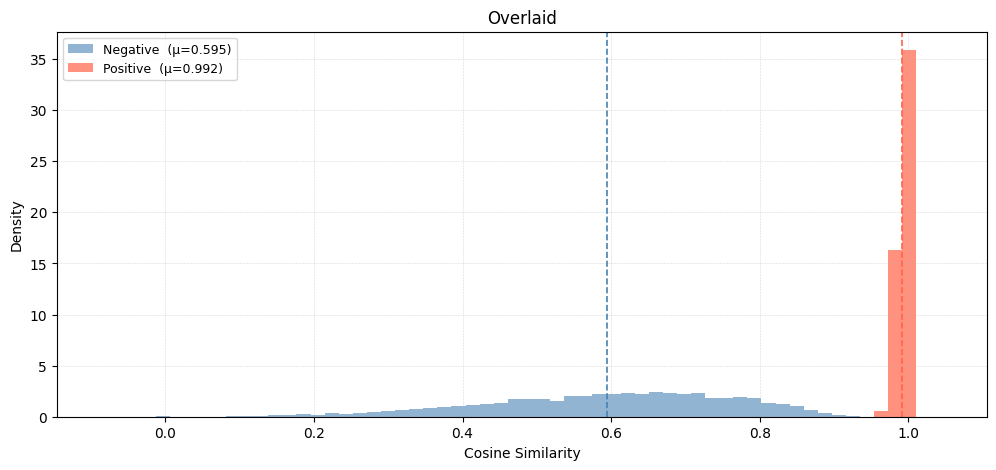

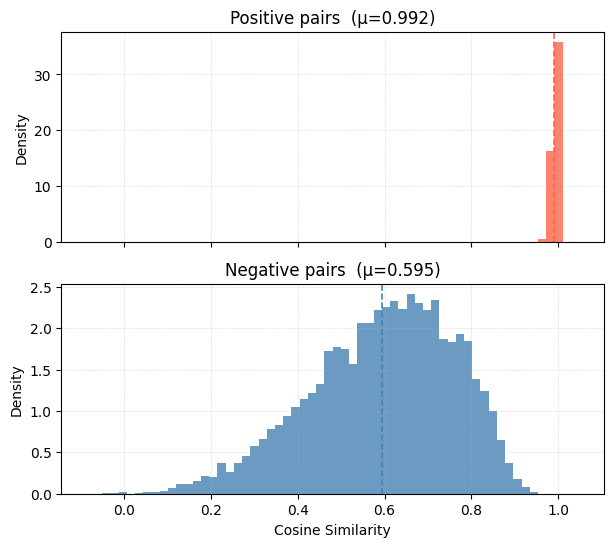

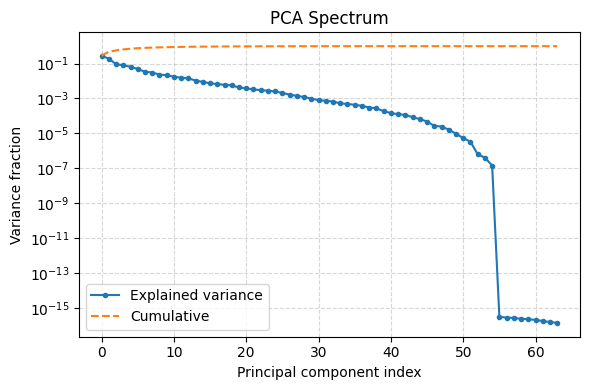

In [52]:
print("Before projection statistics:")


analyze_latent_similarity(latents_og_wo_proj, latents_aug_no_rot_wo_proj);

analyze_latent_space(np.vstack([latents_og_wo_proj, latents_aug_no_rot_wo_proj]), tol=1e-3);


After projection statistics:
Shape: N=200, D=64
Total variance: 1.7052e+00
Top eigenvalue fraction: 0.7361
Effective dimension (entropy): 2.97
Participation ratio: 1.78
Estimated rank: 21/64
95% variance is in 7/64 dimensions
⚠️ Possible dimensional collapse (rank significantly reduced)
⚠️ Strong anisotropy (one principal direction dominates)


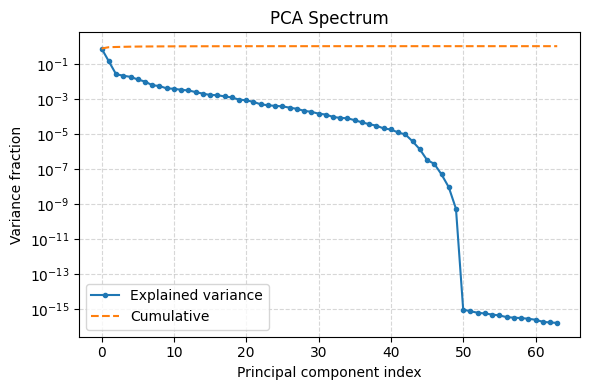

Number of events        : 200
Positive pairs          : 200
Negative pairs (used)   : 39,800
────────────────────────────────────────
Mean cosine sim (positive) : 1.0000
Standard deviation cosine sim (positive) : 0.0000
Mean cosine sim (negative) : 0.8192
Standard deviation cosine sim (negative) : 0.1531
Separation (pos - neg)     : 0.1808


{'pos_similarities': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'neg_similarities': array([0.90173979, 0.80808367, 0.76912168, ..., 0.5403386 , 0

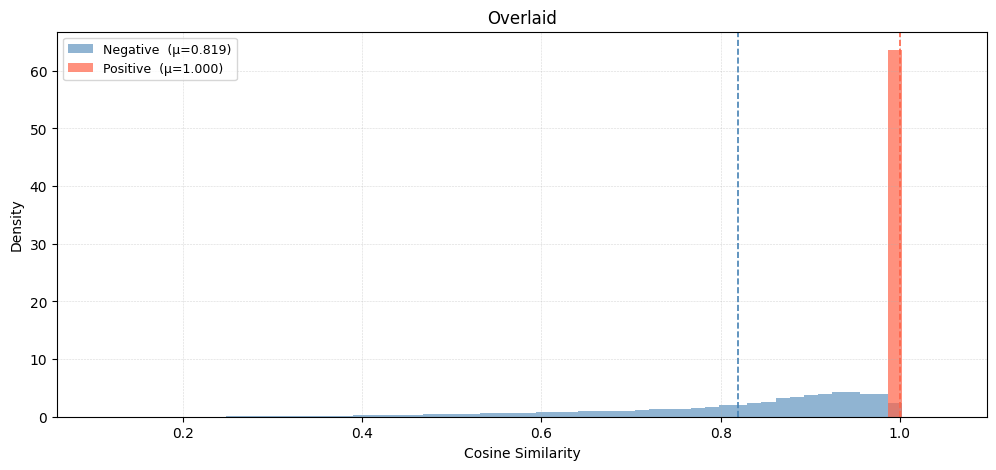

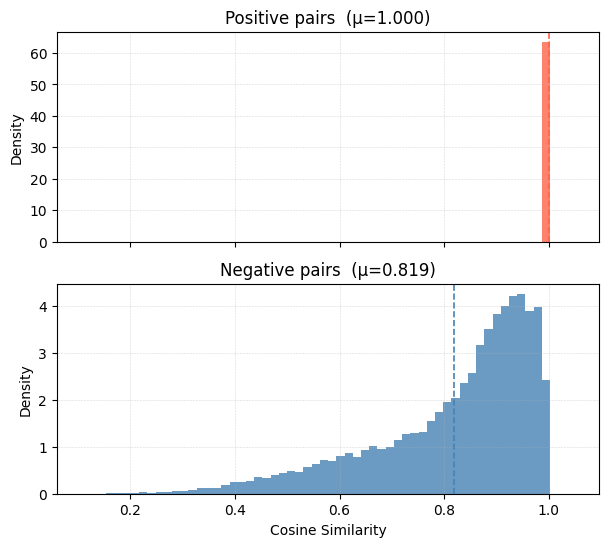

In [11]:
split = 'dihiggs_scale_5.0_cylin'


rot = np.pi/8
energy_noise = 0.05

folder = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml_latest/gravnet_models_{}_rot_{:.2f}_noise_{:.2f}/'.format(split, rot, energy_noise)



latents_og_wo_proj = np.loadtxt(folder+'without_projection_'+'dihiggs_original_900-1100_latents_epoch_20.txt')
#latents_aug_wo_proj = np.loadtxt(folder+'without_projection_'+'dihiggs_augmented_900-1000_latents_epoch_20.txt')



print("After projection statistics:")




analyze_latent_space(latents_og_wo_proj, tol=1e-3);


analyze_latent_similarity(latents_og_wo_proj, latents_og_wo_proj)

In [15]:
"""
Regression Task
"""

from colliderml.core import load_tables, collect_tables
## dihiggs data
cfg2 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "dihiggs",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": 1100,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables2 = load_tables(cfg2)
frames2 = collect_tables(tables2)

calo_hits2 = frames2["calo_hits"][900:1100]

dataset_test_dihiggs = ColliderMLHits(calo_hits2, "val", shuffle_files=False, train_fraction=0.0)


x_extent = []
y_extent = []
z_extent = []

for data in dataset_test_dihiggs:

    x_extent.append(max(data['calo_hit_features'][:,0])-min(data['calo_hit_features'][:,0]))
    y_extent.append(max(data['calo_hit_features'][:,1])-min(data['calo_hit_features'][:,1]))
    z_extent.append(max(data['calo_hit_features'][:,2])-min(data['calo_hit_features'][:,2]))



In [23]:
linear_probe_regression2(latents_og_wo_proj, np.array(y_extent));

Fold     Train R²    Test R²     Test MSE
------------------------------------------
1          0.2331     0.1126  370105.3070
2          0.2429     0.0594  464433.1312
3          0.2408     0.1190  285644.6903
4          0.2633    -0.0112  276856.1242
5          0.2445     0.1300  484645.8514
------------------------------------------
Mean       0.2449     0.0820  376337.0208
Std        0.0100     0.0525   86778.0033

Best alpha (last fold): 100.0
